# Regression Anysis

## 시뮬레이션 요약

이 노트북은 두 그룹에서 수집된 2차원 데이터의 선형 관계를, 빈도주의(Frequentist)와 베이지안(Bayesian) 접근으로 비교 분석하는 시뮬레이션이다.

1. 데이터 생성: 공분산 $\mathrm{diag}(1, 9)$를 갖는 이변량 정규표본을 각 100개씩 생성하고 30도 회전한 뒤, 그룹 2를 $[0, 2]$만큼 이동시켜 그룹 간 절편 차이를 의도적으로 만든다.
2. 시각화: 그룹 표시/비표시 산점도로 전체 패턴과 그룹 구조를 확인한다.
3. 빈도주의 회귀: 
   - 그룹 무시 OLS로 전체 추세와 p-value, 신뢰구간(CI)을 확인한다.
   - 그룹 반영 OLS(`B ~ A * C(group_id)`)로 절편/기울기의 그룹 차이를 검정한다.
4. 베이지안 회귀:
   - 그룹 무시 단순 선형회귀를 Stan/CmdStanPy로 추정하고, 사후분포 및 PPC를 통해 적합도를 점검한다.
   - 그룹 ID를 반영한 다수준(multi-level) 모형을 추정해 부분 풀링(partial pooling) 효과, 그룹별 절편, 공통 기울기, 잔차 분산 변화를 해석한다.
5. 핵심 메시지: 그룹 구조를 모형에 반영하면(특히 다수준 모형) 잔차 분산 추정과 사후예측이 개선되며, 모수 불확실성을 사후분포로 더 풍부하게 해석할 수 있다.


In [1]:
# Generate two Gaussian groups, rotate them 30 degrees CCW, shift the second group, and merge into A and B.
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n_points = 100
mean = np.array([0.0, 0.0])
covariance = np.array([[1.0, 0.0], [0.0, 3.0**2]])

group_1 = rng.multivariate_normal(mean, covariance, size=n_points)
group_2 = rng.multivariate_normal(mean, covariance, size=n_points)

theta = np.deg2rad(30)
rotation = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)],
])

group_1 = group_1 @ rotation.T
group_2 = group_2 @ rotation.T
group_2 += np.array([0.0, 2.0])

A1, B1 = group_1.T
A2, B2 = group_2.T
A = np.concatenate([A1, A2])
B = np.concatenate([B1, B2])

data = np.column_stack([A, B])  # Agreegated data; not used in the rest of the code, but can be useful for visualization or other purposes.

# Create a DataFrame with columns A, B, and group_id (1 for group_1 and 2 for group_2).
df = pd.DataFrame(
    {
        "A": A,
        "B": B,
        "group_id": np.repeat([1, 2], n_points),
    }
)

df.head()

,A,B,group_id
0,-1.357728,0.271686,1
1,-0.311124,2.420012,1
2,1.798832,-5.720028,1
3,-0.465635,0.174018,1
4,-0.713556,-0.470173,1


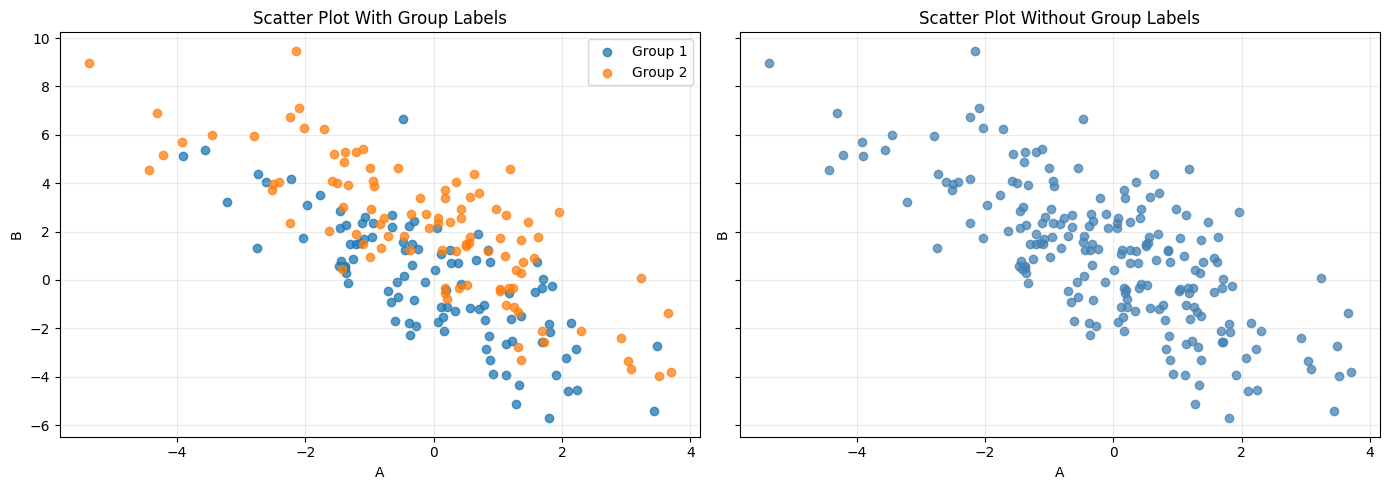

In [2]:
# Draw scatter plots with and without group labels.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for group_id, group_df in df.groupby("group_id"):
    axes[0].scatter(group_df["A"], group_df["B"], alpha=0.75, label=f"Group {group_id}")

axes[0].set_title("Scatter Plot With Group Labels")
axes[0].set_xlabel("A")
axes[0].set_ylabel("B")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].scatter(df["A"], df["B"], color="steelblue", alpha=0.75)
axes[1].set_title("Scatter Plot Without Group Labels")
axes[1].set_xlabel("A")
axes[1].set_ylabel("B")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 그룹 정보를 사용하지 않은 회귀분석(Regression Analysis) 이론

그룹 정보를 무시하면, 모든 관측값이 하나의 모집단(population)에서 나왔다고 보고 하나의 선형회귀모형(linear regression model)을 적합합니다.

$$
B_i = \beta_0 + \beta_1 A_i + \varepsilon_i
$$

여기서 $\beta_0$는 절편(intercept), $\beta_1$은 $A$가 1만큼 증가할 때 평균적으로 $B$가 얼마나 변하는지를 나타내는 기울기(slope)이며, $\varepsilon_i$는 모형이 설명하지 못하는 오차항(error term)입니다. 최소제곱법(ordinary least squares, OLS)은 잔차제곱합(sum of squared residuals)을 최소화하도록 $\beta_0$와 $\beta_1$을 추정합니다.

이처럼 모든 데이터를 하나로 합쳐 분석하는 방식은 전체적인 선형 추세(linear trend)를 요약하는 데는 유용하지만, 서로 다른 그룹 때문에 생기는 구조(structure)를 가릴 수 있습니다. 실제로 그룹마다 평균(mean)이나 관계(relationship)가 다르면, 하나의 회귀선(regression line)은 그러한 차이를 섞어서 보여주게 됩니다.

## p-value 설명

p-value는 귀무가설(null hypothesis)이 참이라고 가정했을 때, 지금 관측된 결과와 같거나 그보다 더 극단적인 결과가 나올 확률입니다. 이 회귀분석에서는 보통 귀무가설을 $H_0: \beta_1 = 0$으로 둡니다. 즉, 설명변수(explanatory variable) $A$가 반응변수(response variable) $B$와 선형 관계(linear relationship)가 없다고 가정합니다.

만약 p-value가 매우 작다면, 현재 데이터는 $\beta_1 = 0$이라는 가정과 잘 맞지 않는다는 뜻입니다. 따라서 귀무가설(null hypothesis)을 기각(reject)하고, $A$와 $B$ 사이에 통계적으로 유의한(statistically significant) 선형 관계가 있다고 해석합니다. 반대로 p-value가 크다면, 기울기(slope)가 0이 아니라는 충분한 근거(evidence)가 없다고 봅니다.

다만 p-value는 효과의 크기(effect size) 자체를 말해주지는 않습니다. 따라서 계수(coefficient)의 크기, 95% 신뢰구간(confidence interval), 그리고 산점도(scatter plot)와 회귀선(regression line)을 함께 보는 것이 더 적절합니다.

                            OLS Regression Results                            
Dep. Variable:                      B   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     222.8
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           2.96e-34
Time:                        11:42:36   Log-Likelihood:                -417.83
No. Observations:                 200   AIC:                             839.7
Df Residuals:                     198   BIC:                             846.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9635      0.139      6.931      0.0

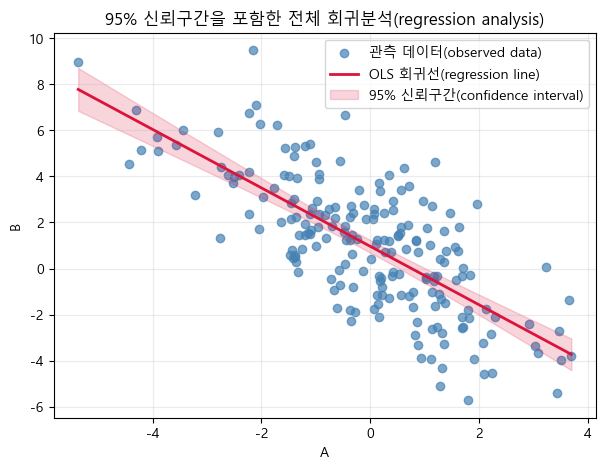

In [3]:
# group_id를 사용하지 않고 전체 데이터를 대상으로 단순선형회귀(Simple Linear Regression)를 적합한다.
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

X = sm.add_constant(df[["A"]], has_constant="add") # 독립변수(independent variable) 또는 설명변수(explanatory variable)
y = df["B"] # 종속변수(dependent variable) 또는 반응변수(response variable)

# ------------------------------------------------------------------------
# Ordinary Least Squares(OLS) 회귀모형(regression model)을 적합(fit)한다. 
# y = β0 + β1 * A + ε
ols_model = sm.OLS(y, X).fit() 

# ------------------------------------------------------------------------
print(ols_model.summary())

slope_p_value = ols_model.pvalues["A"]
confidence_interval = ols_model.conf_int().loc["A"]
print(f"\n기울기(slope) p-value: {slope_p_value:.4g}")
print(f"기울기(slope)의 95% 신뢰구간(confidence interval): [{confidence_interval[0]:.4f}, {confidence_interval[1]:.4f}]")
if slope_p_value < 0.05:
    print("해석(interpretation): 유의수준(significance level) 5%에서 귀무가설(null hypothesis) H0를 기각한다. A와 B 사이에 통계적으로 유의한(statistically significant) 선형 관계(linear relationship)가 있다.")
else:
    print("해석(interpretation): 유의수준(significance level) 5%에서 귀무가설(null hypothesis) H0를 기각하지 못한다. A와 B 사이의 선형 관계(linear relationship)에 대한 근거(evidence)가 충분하지 않다.")

x_grid = np.linspace(df["A"].min(), df["A"].max(), 200)
X_grid = sm.add_constant(pd.DataFrame({"A": x_grid}), has_constant="add")
prediction = ols_model.get_prediction(X_grid).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["A"], df["B"], color="steelblue", alpha=0.7, label="관측 데이터(observed data)")
ax.plot(x_grid, prediction["mean"], color="crimson", linewidth=2, label="OLS 회귀선(regression line)")
ax.fill_between(
    x_grid,
    prediction["mean_ci_lower"],
    prediction["mean_ci_upper"],
    color="crimson",
    alpha=0.18,
    label="95% 신뢰구간(confidence interval)",
)
ax.set_title("95% 신뢰구간을 포함한 전체 회귀분석(regression analysis)")
ax.set_xlabel("A")
ax.set_ylabel("B")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 신뢰구간(Confidence Interval)이 중앙에서 좁고 바깥에서 넓어지는 이유

회귀선(regression line) 주변의 95% 신뢰구간(confidence interval)은 보통 $A$ 값의 중앙 부근에서 가장 좁고, 양쪽 끝으로 갈수록 넓어집니다. 가장 중요한 이유는 데이터가 많이 모여 있는 구간에서 회귀선이 더 정확하게 추정되기 때문입니다.

단순선형회귀(simple linear regression)에서 $A=a$일 때 적합된 평균값(fitted mean)의 표준오차(standard error)는 다음 식에 비례합니다.

$$
\sqrt{\frac{1}{n} + \frac{(a - \bar{A})^2}{\sum_{i=1}^n (A_i - \bar{A})^2}}
$$

이 식은 $a$가 표본평균(sample mean) $\bar{A}$에 가까울수록 가장 작아집니다. 반대로 $a$가 $\bar{A}$에서 멀어질수록 $(a - \bar{A})^2$ 항이 커지므로 불확실성(uncertainty)이 증가하고, 그 결과 신뢰구간(confidence interval)도 넓어집니다.

직관적으로 보면 중앙 구간은 데이터가 좌우에 고르게 존재하므로 회귀선(regression line)의 평균 추정(mean estimation)이 더 안정적입니다. 반면 바깥 구간은 가까운 관측값(observations)이 상대적으로 적고, 기울기(slope)나 절편(intercept)이 조금만 달라져도 예측값(predicted value)이 더 크게 흔들릴 수 있으므로 신뢰구간(confidence band)이 퍼지게 됩니다.


특정 $A=a$에서 그림의 95% 신뢰구간은  $E[B\mid A=a]$의 “존재구간”이라기보다,  **모평균 반응(mean response) $E[B\mid A=a]$에 대한 추정 신뢰구간(confidence interval)** 입니다.

즉 해석은 다음과 같습니다.

1. 같은 방식으로 표본추출과 회귀적합을 매우 많이 반복하면, 그렇게 만든 구간들 중 약 95%가 참값 $E[B\mid A=a]$를 포함합니다.
2. 현재 한 번 만든 이 구간에 대해 “참값이 95% 확률로 이 안에 있다”라고 엄밀한 빈도주의 해석을 하지는 않습니다.
3. 개별 관측치 $B$ 자체의 범위를 말하고 싶다면 신뢰구간이 아니라 예측구간(prediction interval)을 봐야 하며, 그 구간이 더 넓습니다.

## OLS 요약표(OLS Summary) 한국어 해설

### 1) 모형 전체 적합도(Model Fit)

- 결정계수(R-squared): 모델이 반응변수(response variable) 변동을 얼마나 설명하는지 나타냅니다. 값이 0.53이면, 전체 변동의 약 53%를 선형회귀(linear regression)가 설명한다는 뜻입니다.
- 수학적 정의(mathematical definition):

\begin{align}
  R^2 & = 1 - \frac{\mathrm{SSE}}{\mathrm{SST}} 
   = 1 - \frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2} \\
  & = 1 - \frac{(1/n)\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{(1/n)\sum_{i=1}^{n}(y_i-\bar{y})^2}
\end{align}

  - 잔차제곱합(SSE, sum of squared errors): $\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$
  - 전체제곱합(SST, total sum of squares)은 $\sum_{i=1}^{n}(y_i-\bar{y})^2$

- 수정 결정계수(Adj. R-squared): 설명변수 개수를 보정한 결정계수입니다. 단순회귀(simple regression)에서는 R-squared와 큰 차이가 나지 않는 것이 일반적입니다.

### 2) 모형 유의성(Model Significance)

- F-통계량(F-statistic)과 Prob(F-statistic): 회귀모형 전체가 유의한지 검정합니다.
- Prob(F-statistic)이 매우 작으면(예: 0.05보다 훨씬 작음), "설명변수의 효과가 모두 0"이라는 귀무가설(null hypothesis)을 기각합니다.

### 3) 계수표(Coefficient Table)

- coef: 추정된 계수(coefficient)입니다.
  - const(절편, intercept): A=0일 때의 평균 B 추정값입니다.
  - A의 계수(기울기, slope): A가 1 증가할 때 B의 평균이 얼마나 변하는지 의미합니다.
- std err(표준오차, standard error): 계수 추정의 불확실성(uncertainty) 크기입니다.
- t, P>|t|: 각 계수가 0인지에 대한 개별 가설검정(hypothesis test) 결과입니다.
  - p-value가 매우 작으면 해당 계수는 통계적으로 유의(statistically significant)합니다.
- [0.025, 0.975]: 계수의 95% 신뢰구간(confidence interval)입니다.
  - 구간에 0이 포함되지 않으면, 유의수준 5%에서 유의하다고 해석할 수 있습니다.

### 4) 현재 결과의 핵심 해석(Interpretation)

- A의 기울기(slope)는 음수(negative)이므로, A가 커질수록 B는 평균적으로 감소하는 경향이 있습니다.
- A의 p-value가 매우 작으므로, A와 B 사이의 선형 관계(linear relationship)는 통계적으로 유의합니다.
- 기울기의 95% 신뢰구간이 전부 음수 구간이면, 감소 경향이 우연이라기보다 일관된 신호(signal)일 가능성이 큽니다.

### 5) 함께 보면 좋은 지표(Additional Checks)

- Durbin-Watson: 잔차(residual)의 자기상관(autocorrelation) 여부를 점검할 때 봅니다.
- Omnibus, Jarque-Bera: 잔차 정규성(normality)을 참고하는 지표입니다.
- 실제 분석에서는 잔차진단(residual diagnostics), 이상치(outlier), 이분산성(heteroscedasticity)도 함께 확인하는 것이 좋습니다.

---
## Group Id 를 반영한 해석

기준 그룹을 `group_id=1`, 비교 그룹을 `group_id=2`로 두면 지시변수(indicator) $G_i=\mathbb{1/0}$에 대해

$$
B_i = \beta_0 + \beta_1 A_i + \beta_2 G_i + \beta_3 (A_i G_i) + \varepsilon_i,
\quad \varepsilon_i \sim N(0,\sigma^2)
$$

- 그룹 1 (`G_i=0`):
$$
E[B_i\mid A_i, G_i=0] = \beta_0 + \beta_1 A_i
$$
- 그룹 2 (`G_i=1`):
$$
E[B_i\mid A_i, G_i=1] = (\beta_0+\beta_2) + (\beta_1+\beta_3)A_i
$$


1. 적합(fit)을 한 번만 한다  
   `B ~ A * C(group_id)`는 하나의 설계행렬(design matrix)을 만들고 OLS를 한 번 수행합니다.

2. 모형식이 하나다  
   $$B_i=\beta_0+\beta_1A_i+\beta_2G_i+\beta_3(A_iG_i)+\varepsilon_i
   $$  
   여기서 $G_i$는 그룹 더미 변수입니다.  
   즉, 계수 $\beta_0,\beta_1,\beta_2,\beta_3$를 “동시에” 추정합니다.

3. 상호작용항이 그룹별 기울기 차이를 만든다  
   $A_iG_i$ 항 때문에 그룹 2의 기울기가 $\beta_1+\beta_3$가 됩니다.  
   그래서 결과적으로 두 직선이 생기지만, 출발점은 “두 개의 별도 회귀”가 아니라 “한 개의 회귀 + 상호작용항”입니다.

4. 두 개를 따로 돌리는 것과 통계적으로 다르다  
   따로 돌리면 각 그룹의 오차분산/표준오차를 독립적으로 처리하지만, 상호작용 모형은 한 프레임에서 계수 차이(예: $\beta_3=0$)를 직접 검정할 수 있습니다.


In [4]:
# group_id를 반영한 회귀분석: 그룹별 절편/기울기 차이를 함께 추정
import statsmodels.formula.api as smf

ols_additive_model = smf.ols("B ~ A * C(group_id)", data=df).fit()
print(ols_additive_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      B   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.9
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           2.36e-46
Time:                        11:42:36   Log-Likelihood:                -383.77
No. Observations:                 200   AIC:                             775.5
Df Residuals:                     196   BIC:                             788.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0847      0

In [5]:
print("\n모형 해석 포인트")
print(f"- Intercept: 기준 그룹(group_id=1)에서 A=0일 때의 평균 B: {ols_additive_model.params['Intercept']: .4f}")
print(f"- A: 기준 그룹(group_id=1)의 기울기: {ols_additive_model.params['A']: .4f}")
print(f"- C(group_id)[T.2]: group_id=2의 절편 차이: {ols_additive_model.params['C(group_id)[T.2]']: .4f}")
print(f"- A:C(group_id)[T.2]: group_id=2의 기울기 차이: {ols_additive_model.params['A:C(group_id)[T.2]']: .4f}")


모형 해석 포인트
- Intercept: 기준 그룹(group_id=1)에서 A=0일 때의 평균 B: -0.0847
- A: 기준 그룹(group_id=1)의 기울기: -1.3054
- C(group_id)[T.2]: group_id=2의 절편 차이:  2.1011
- A:C(group_id)[T.2]: group_id=2의 기울기 차이:  0.0887


## 그룹 ID를 반영한 회귀식 해설

### 1) `B ~ A * C(group_id)`의 의미

- `B`: 반응변수(response variable)
- `A`: 연속형 설명변수(explanatory variable)
- `C(group_id)`: `group_id`를 범주형(categorical) 변수로 처리
- `*` 연산자: 주효과(main effects)와 상호작용(interaction)을 모두 포함

따라서 실제로는 다음과 같은 항을 포함합니다.

- 절편(intercept)
- `A`
- `C(group_id)`
- `A:C(group_id)`

즉, 그룹별로 절편과 기울기가 다른지를 동시에 검정하는 모형입니다.

### 2) OLS를 위한 수학적 모델

기준 그룹을 `group_id=1`, 비교 그룹을 `group_id=2`로 두면 지시변수(indicator) $G_i=\mathbb{1}(group_i=2)$에 대해

$$
B_i = \beta_0 + \beta_1 A_i + \beta_2 G_i + \beta_3 (A_i G_i) + \varepsilon_i,
\quad \varepsilon_i \sim N(0,\sigma^2)
$$

- 그룹 1 (`G_i=0`):
$$
E[B_i\mid A_i, G_i=0] = \beta_0 + \beta_1 A_i
$$
- 그룹 2 (`G_i=1`):
$$
E[B_i\mid A_i, G_i=1] = (\beta_0+\beta_2) + (\beta_1+\beta_3)A_i
$$

### 3) OLS 출력값 해석

- `Intercept`: 기준 그룹(group 1)의 절편
- `A`: 기준 그룹(group 1)의 기울기
- `C(group_id)[T.2]`: 그룹 2가 그룹 1 대비 갖는 절편 차이
- `A:C(group_id)[T.2]`: 그룹 2가 그룹 1 대비 갖는 기울기 차이
- `P>|t|`: 각 계수의 유의성(significance) 검정 p-value
- `R-squared`: 모형 설명력

현재 출력에서는 대체로 다음처럼 읽습니다.

- `C(group_id)[T.2]`가 유의하면: 두 그룹의 절편 차이가 유의
- `A:C(group_id)[T.2]`가 비유의이면: 두 그룹 기울기 차이는 뚜렷하지 않음

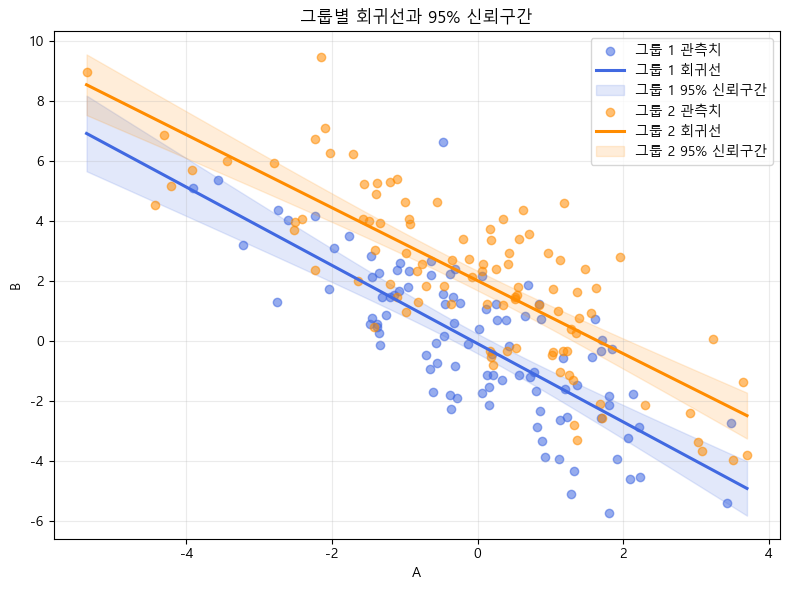

In [6]:
# 그룹별 회귀선 2개와 95% 신뢰구간 시각화
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

if "model_with_group" not in globals():
    import statsmodels.formula.api as smf
    model_with_group = smf.ols("B ~ A * C(group_id)", data=df).fit()

a_min, a_max = df["A"].min(), df["A"].max()
a_grid = np.linspace(a_min, a_max, 200)

pred_frames = []
for gid in [1, 2]:
    pred_input = pd.DataFrame({"A": a_grid, "group_id": gid})
    pred = model_with_group.get_prediction(pred_input).summary_frame(alpha=0.05)
    pred_frames.append(
        pd.DataFrame(
            {
                "A": a_grid,
                "mean": pred["mean"].values,
                "lower": pred["mean_ci_lower"].values,
                "upper": pred["mean_ci_upper"].values,
                "group_id": gid,
            }
        )
    )

pred_df = pd.concat(pred_frames, ignore_index=True)
colors = {1: "royalblue", 2: "darkorange"}

fig, ax = plt.subplots(figsize=(8, 6))
for gid in [1, 2]:
    group_data = df[df["group_id"] == gid]
    group_pred = pred_df[pred_df["group_id"] == gid]

    ax.scatter(
        group_data["A"],
        group_data["B"],
        color=colors[gid],
        alpha=0.55,
        label=f"그룹 {gid} 관측치",
    )
    ax.plot(
        group_pred["A"],
        group_pred["mean"],
        color=colors[gid],
        linewidth=2.2,
        label=f"그룹 {gid} 회귀선",
    )
    ax.fill_between(
        group_pred["A"],
        group_pred["lower"],
        group_pred["upper"],
        color=colors[gid],
        alpha=0.15,
        label=f"그룹 {gid} 95% 신뢰구간",
    )

ax.set_title("그룹별 회귀선과 95% 신뢰구간")
ax.set_xlabel("A")
ax.set_ylabel("B")
ax.grid(alpha=0.25)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="best")
plt.tight_layout()
plt.show()

## OLS Regression with Single Slope

`B ~ A + C(group_id)`는 **그룹별 절편은 다르되, 기울기는 하나만 공유**하는 OLS 모형이다.

- `A`: 연속형 설명변수(main effect)
- `C(group_id)`: 그룹 더미 변수(main effect)
- 상호작용항 `A:C(group_id)`는 포함하지 않음

수학적으로는 (기준그룹을 $G_i=0$, 비교그룹을 $G_i=1$로 둘 때)

$$
B_i = \beta_0 + \beta_1 A_i + \beta_2 G_i + \varepsilon_i
$$

따라서 그룹별 평균식은

$$
E[B_i \mid A_i, G_i=0] = \beta_0 + \beta_1 A_i
$$

$$
E[B_i \mid A_i, G_i=1] = (\beta_0 + \beta_2) + \beta_1 A_i
$$

즉,

1. 기울기(slope): 두 그룹 모두 $\beta_1$로 동일(평행한 두 직선)
2. 절편(intercept): 그룹 간 차이는 $\beta_2$
3. 검정 포인트: `C(group_id)`의 p-value는 절편 차이 유의성, `A`의 p-value는 공통 기울기 유의성을 의미

참고: `B ~ A * C(group_id)`를 쓰면 $A:C(group\_id)$가 추가되어 그룹별 기울기까지 달라지는 상호작용(interaction) 모형이 된다.


In [15]:
import statsmodels.formula.api as smf

# 단일 기울기 + 그룹별 절편 OLS
ols_additive_model = smf.ols("B ~ A + C(group_id)", data=df).fit()
print(ols_additive_model.summary())


                            OLS Regression Results                            
Dep. Variable:                      B   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     195.3
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.78e-47
Time:                        12:06:15   Log-Likelihood:                -383.95
No. Observations:                 200   AIC:                             773.9
Df Residuals:                     197   BIC:                             783.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0837      0.166  

In [16]:
print("\n핵심 계수")
print(f"공통 기울기 beta (A): {ols_additive_model.params['A']:.4f}")
print(f"기준그룹 절편 (group_id=1): {ols_additive_model.params['Intercept']:.4f}")
print(f"절편 차이 (group_id=2 - group_id=1): {ols_additive_model.params['C(group_id)[T.2]']:.4f}")


핵심 계수
공통 기울기 beta (A): -1.2513
기준그룹 절편 (group_id=1): -0.0837
절편 차이 (group_id=2 - group_id=1): 2.0966


---
## Bayesian Inference w/o Group Id

In [7]:
# Stan 모델 파일 작성 및 CmdStanPy로 MCMC 추정
import pathlib
import numpy as np
from cmdstanpy import CmdStanModel

stan_code = """
data {
    int<lower=0> N;
    vector[N] A;
    vector[N] B;
}
parameters {
    real beta0;
    real beta1;
    real<lower=0> sigma;
}
model {
    beta0 ~ normal(0, 10);
    beta1 ~ normal(0, 10);
    sigma ~ exponential(1);
    B ~ normal(beta0 + beta1 * A, sigma);
}
generated quantities {
    vector[N] B_rep;
    for (n in 1:N)
        B_rep[n] = normal_rng(beta0 + beta1 * A[n], sigma);
}
"""

stan_file = pathlib.Path("linear_regression.stan")
stan_file.write_text(stan_code)

model = CmdStanModel(stan_file=str(stan_file))

stan_data = {"N": len(df), "A": df["A"].tolist(), "B": df["B"].tolist()}

fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True,
)

summary = fit.summary()
print(summary.loc[["beta0", "beta1", "sigma"]])

11:42:37 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\Downloads\KOS-5101\misc\linear_regression.stan to exe file C:\Users\yongduek\Downloads\KOS-5101\misc\linear_regression.exe
11:42:51 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\Downloads\KOS-5101\misc\linear_regression.exe
11:42:52 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

11:42:52 - cmdstanpy - INFO - CmdStan done processing.



           Mean      MCSE    StdDev       MAD        5%       50%      95%  \
beta0  0.962945  0.002286  0.139095  0.138868  0.728412  0.965763  1.18897   
beta1 -1.266930  0.001344  0.084149  0.081730 -1.406640 -1.266870 -1.12663   
sigma  1.965160  0.001634  0.101269  0.100537  1.805700  1.960410  2.13848   

       ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
beta0   3751.42   2701.37     5291.15  1.00097  
beta1   3939.67   3036.89     5556.66  1.00113  
sigma   4033.57   2625.12     5689.10  1.00014  


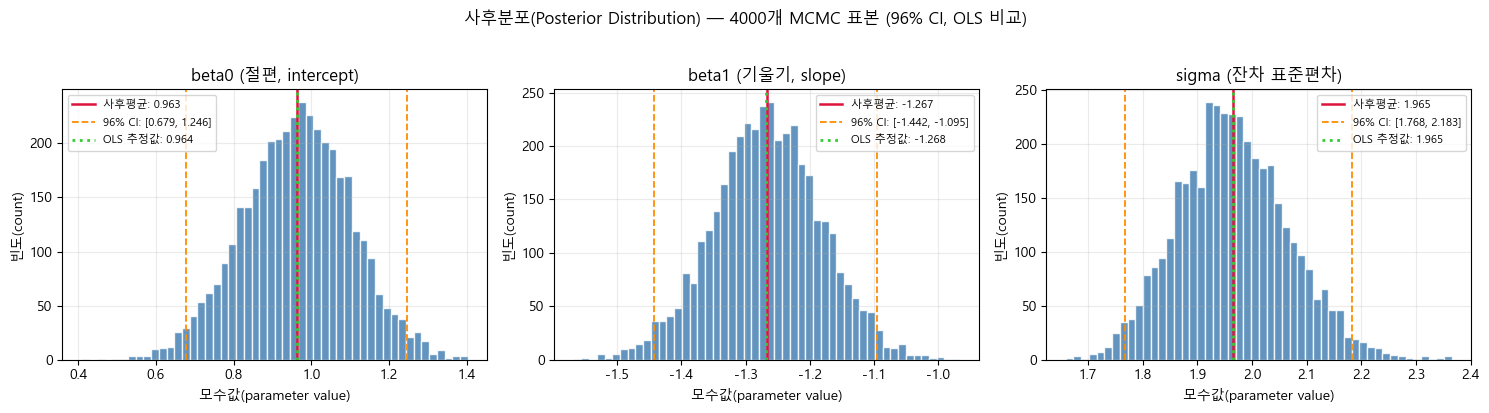

In [8]:

# 사후분포(posterior distribution) 시각화 + OLS 추정값 비교
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

draws = fit.draws_pd()

# OLS 추정값 (비교 기준)
ols_beta0 = ols_model.params["const"]
ols_beta1 = ols_model.params["A"]
ols_sigma  = np.sqrt(ols_model.mse_resid)

params = {
    "beta0 (절편, intercept)": (draws["beta0"].values, ols_beta0),
    "beta1 (기울기, slope)":   (draws["beta1"].values, ols_beta1),
    "sigma (잔차 표준편차)":   (draws["sigma"].values, ols_sigma),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (samples, ols_val)) in zip(axes, params.items()):
    ax.hist(samples, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    lo, hi = np.percentile(samples, [2, 98])
    ax.axvline(samples.mean(), color="crimson", linewidth=1.8,
               label=f"사후평균: {samples.mean():.3f}")
    ax.axvline(lo, color="darkorange", linewidth=1.3, linestyle="--",
               label=f"96% CI: [{lo:.3f}, {hi:.3f}]")
    ax.axvline(hi, color="darkorange", linewidth=1.3, linestyle="--")
    ax.axvline(ols_val, color="limegreen", linewidth=2.0, linestyle=":",
               label=f"OLS 추정값: {ols_val:.3f}")
    ax.set_title(name)
    ax.set_xlabel("모수값(parameter value)")
    ax.set_ylabel("빈도(count)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

plt.suptitle("사후분포(Posterior Distribution) — 4000개 MCMC 표본 (96% CI, OLS 비교)", y=1.02)
plt.tight_layout()
plt.show()


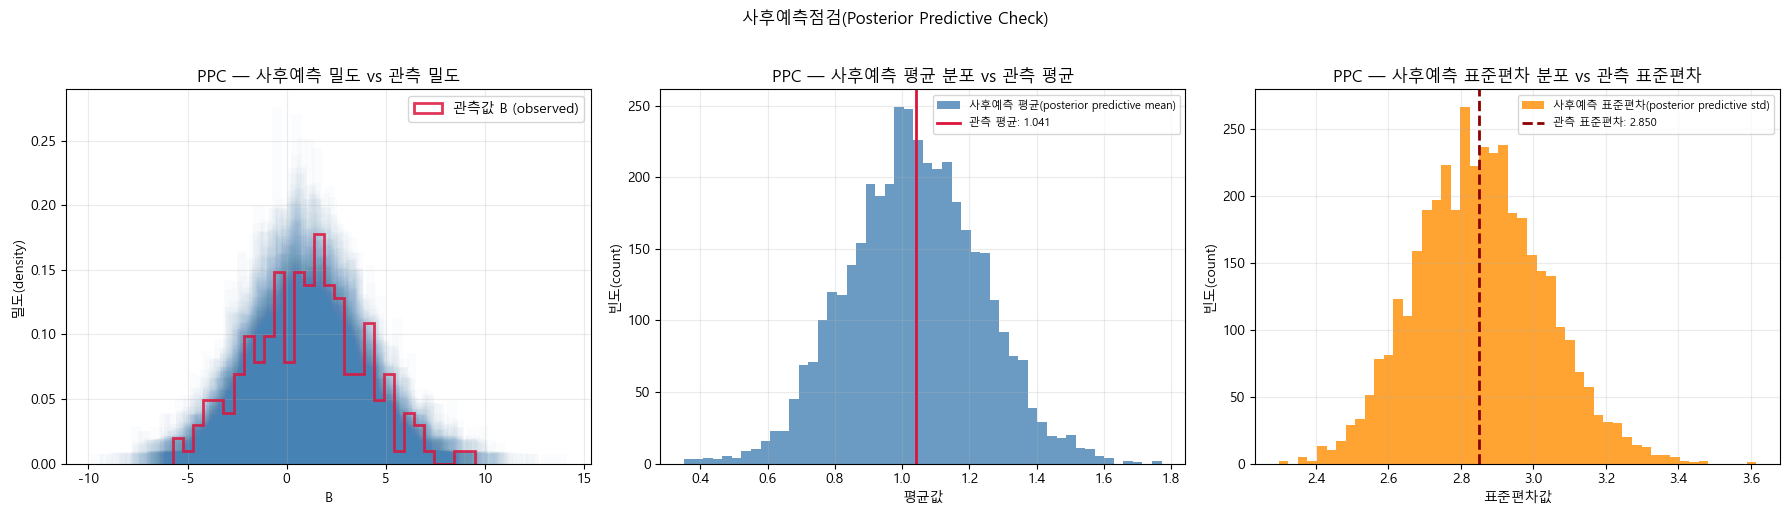

In [9]:

# 사후예측점검(Posterior Predictive Check, PPC)
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# B_rep 컬럼 추출 (N개 × 4000 MCMC 표본)
b_rep_cols = [c for c in draws.columns if c.startswith("B_rep")]
B_rep = draws[b_rep_cols].values  # shape: (4000, N)

B_obs = df["B"].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 왼쪽: 사후예측 밀도 vs 관측 밀도
ax = axes[0]
n_overlay = 200
idx = np.random.choice(B_rep.shape[0], n_overlay, replace=False)
for i in idx:
    ax.hist(B_rep[i], bins=30, density=True,
            color="steelblue", alpha=0.02, histtype="stepfilled")
ax.hist(B_obs, bins=30, density=True,
        color="crimson", alpha=0.85, histtype="step",
        linewidth=2, label="관측값 B (observed)")
ax.set_title("PPC — 사후예측 밀도 vs 관측 밀도")
ax.set_xlabel("B")
ax.set_ylabel("밀도(density)")
ax.legend()
ax.grid(alpha=0.25)

# ── 가운데: 사후예측 평균 분포 vs 관측 평균
rep_means = B_rep.mean(axis=1)
ax2 = axes[1]
ax2.hist(rep_means, bins=50, color="steelblue", alpha=0.8,
         label="사후예측 평균(posterior predictive mean)")
ax2.axvline(B_obs.mean(), color="crimson", linewidth=2,
            label=f"관측 평균: {B_obs.mean():.3f}")
ax2.set_title("PPC — 사후예측 평균 분포 vs 관측 평균")
ax2.set_xlabel("평균값")
ax2.set_ylabel("빈도(count)")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.25)

# ── 오른쪽: 사후예측 표준편차 분포 vs 관측 표준편차
rep_stds = B_rep.std(axis=1)
ax3 = axes[2]
ax3.hist(rep_stds, bins=50, color="darkorange", alpha=0.8,
         label="사후예측 표준편차(posterior predictive std)")
ax3.axvline(B_obs.std(), color="darkred", linewidth=2,
            linestyle="--", label=f"관측 표준편차: {B_obs.std():.3f}")
ax3.set_title("PPC — 사후예측 표준편차 분포 vs 관측 표준편차")
ax3.set_xlabel("표준편차값")
ax3.set_ylabel("빈도(count)")
ax3.legend(fontsize=8)
ax3.grid(alpha=0.25)

plt.suptitle("사후예측점검(Posterior Predictive Check)", y=1.02)
plt.tight_layout()
plt.show()


---

## Bayesian Inference With Single slope

---
## 다수준 베이지안 회귀분석(Multi-level Bayesian Regression) — 그룹 ID 반영

### 모형 구조

그룹마다 서로 다른 절편(intercept)을 갖되, **부분 풀링(partial pooling)**을 통해 그룹 간 정보를 공유합니다. 기울기(slope)는 두 그룹이 공유합니다.

$$
B_i = \alpha_{g[i]} + \beta\, A_i + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0,\sigma^2)
$$

### 계층적 사전분포(Hierarchical Priors)

$$
\alpha_g \sim \mathcal{N}(\mu_\alpha,\; \tau^2), \quad g = 1, 2
$$

$$
\mu_\alpha \sim \mathcal{N}(0, 10), \quad \tau \sim \text{Exponential}(1)
$$

$$
\beta \sim \mathcal{N}(0, 10), \quad \sigma \sim \text{Exponential}(1)
$$

| 모수 | 의미 |
|------|------|
| $\mu_\alpha$ | 그룹 절편의 모집단 평균(population mean intercept) — 초모수(hyperparameter) |
| $\tau$ | 그룹 간 절편 변동(between-group intercept variation) — 초모수(hyperparameter) |
| $\alpha_1, \alpha_2$ | 각 그룹의 절편(group-specific intercept) — 부분 풀링(partial pooling) 적용 |
| $\beta$ | 두 그룹이 공유하는 기울기(common slope) |
| $\sigma$ | 잔차 표준편차(residual standard deviation) |

완전 풀링(complete pooling)은 그룹 차이를 무시하고, 완전 비풀링(no pooling)은 그룹을 독립적으로 다룹니다.
부분 풀링은 그 중간으로, 그룹이 적거나 데이터가 적을수록 정보를 서로 빌려주는 효과(shrinkage)가 커집니다.


In [10]:

# 다수준(Multi-level) Stan 모델 파일 작성 및 CmdStanPy로 MCMC 추정
import pathlib
import numpy as np
from cmdstanpy import CmdStanModel

stan_ml_code = """
data {
    int<lower=0> N;
    int<lower=0> G;
    array[N] int<lower=1, upper=G> group_id;
    vector[N] A;
    vector[N] B;
}
parameters {
    real mu_alpha;
    real<lower=0> tau;
    vector[G] alpha;
    real beta;
    real<lower=0> sigma;
}
model {
    mu_alpha ~ normal(0, 10);
    tau ~ exponential(1);
    alpha ~ normal(mu_alpha, tau);
    beta ~ normal(0, 10);
    sigma ~ exponential(1);
    for (n in 1:N)
        B[n] ~ normal(alpha[group_id[n]] + beta * A[n], sigma);
}
generated quantities {
    vector[N] B_rep;
    for (n in 1:N)
        B_rep[n] = normal_rng(alpha[group_id[n]] + beta * A[n], sigma);
}
"""

stan_ml_file = pathlib.Path("multilevel_regression.stan")
stan_ml_file.write_text(stan_ml_code)

model_ml = CmdStanModel(stan_file=str(stan_ml_file))

stan_ml_data = {
    "N": len(df),
    "G": int(df["group_id"].nunique()),
    "group_id": df["group_id"].tolist(),
    "A": df["A"].tolist(),
    "B": df["B"].tolist(),
}

fit_ml = model_ml.sample(
    data=stan_ml_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True,
)

summary_ml = fit_ml.summary()
params_to_show = ["mu_alpha", "tau", "alpha[1]", "alpha[2]", "beta", "sigma"]
print(summary_ml.loc[params_to_show])


11:42:56 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\Downloads\KOS-5101\misc\multilevel_regression.stan to exe file C:\Users\yongduek\Downloads\KOS-5101\misc\multilevel_regression.exe
11:43:11 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\Downloads\KOS-5101\misc\multilevel_regression.exe
11:43:12 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

11:43:12 - cmdstanpy - INFO - CmdStan done processing.



              Mean      MCSE    StdDev       MAD        5%       50%  \
mu_alpha  0.940460  0.028863  1.245340  0.931566 -1.114760  0.956107   
tau       1.579730  0.020497  0.825070  0.642480  0.680235  1.374730   
alpha[1] -0.061643  0.002441  0.165614  0.169768 -0.330187 -0.059691   
alpha[2]  1.993870  0.002235  0.159532  0.156205  1.733570  1.993850   
beta     -1.250930  0.001056  0.074956  0.074383 -1.373530 -1.250980   
sigma     1.666460  0.001234  0.084060  0.085842  1.532230  1.666050   

               95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
mu_alpha  2.863430   2299.52   1494.78     1927.51  1.00285  
tau       3.248670   2125.82   1987.34     1781.91  1.00096  
alpha[1]  0.206462   4625.05   2749.36     3876.83  1.00268  
alpha[2]  2.258990   5120.96   3161.42     4292.51  1.00087  
beta     -1.126690   5053.04   3007.04     4235.57  1.00065  
sigma     1.810840   4705.21   2875.50     3944.02  1.00053  


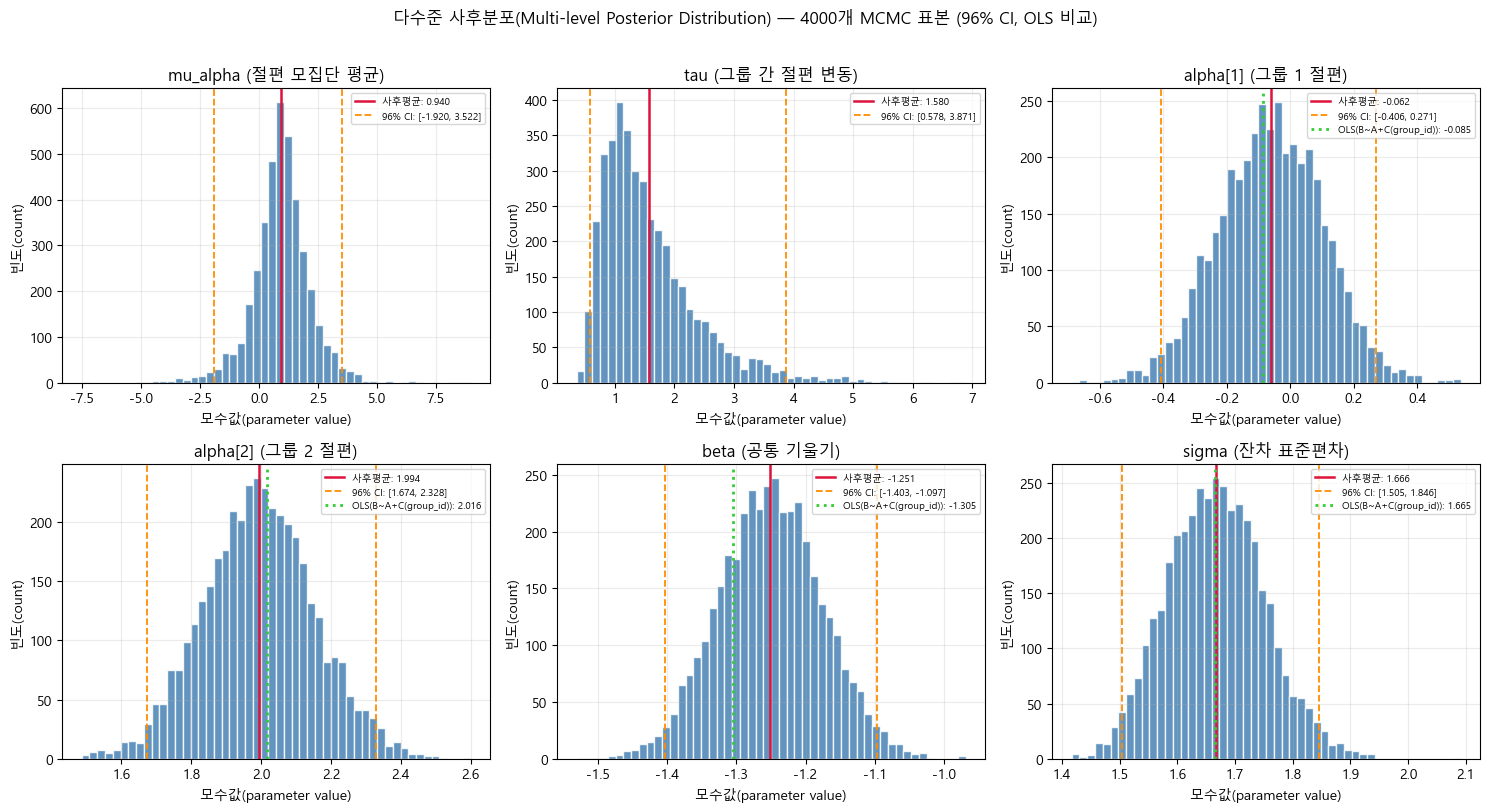

In [ ]:

# 다수준 사후분포(posterior distribution) 시각화 + OLS 비교
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

draws_ml = fit_ml.draws_pd()

# OLS 비교 기준: 다수준 모형과 구조가 대응되는 B ~ A + C(group_id)
# if "ols_additive_model" not in globals():
#     ols_additive_model = smf.ols("B ~ A + C(group_id)", data=df).fit()
#     print("ols_additive_model fitted again for comparison.")

ols_a1 = ols_additive_model.params["Intercept"]
ols_a2 = ols_additive_model.params["Intercept"] + ols_additive_model.params["C(group_id)[T.2]"]
ols_b = ols_additive_model.params["A"]
ols_s = np.sqrt(ols_additive_model.mse_resid)

# 다수준 모형의 주요 모수(parameter)들의 사후분포 샘플
params_ml = {
    "mu_alpha (절편 모집단 평균)": (draws_ml["mu_alpha"].values, None),
    "tau (그룹 간 절편 변동)":     (draws_ml["tau"].values,      None),
    "alpha[1] (그룹 1 절편)":      (draws_ml["alpha[1]"].values, ols_a1),
    "alpha[2] (그룹 2 절편)":      (draws_ml["alpha[2]"].values, ols_a2),
    "beta (공통 기울기)":           (draws_ml["beta"].values,     ols_b),
    "sigma (잔차 표준편차)":        (draws_ml["sigma"].values,    ols_s),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (name, (samples, ols_val)) in zip(axes.ravel(), params_ml.items()):
    ax.hist(samples, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    lo, hi = np.percentile(samples, [2, 98])
    ax.axvline(samples.mean(), color="crimson", linewidth=1.8,
               label=f"사후평균: {samples.mean():.3f}")
    ax.axvline(lo, color="darkorange", linewidth=1.3, linestyle="--",
               label=f"96% CI: [{lo:.3f}, {hi:.3f}]")
    ax.axvline(hi, color="darkorange", linewidth=1.3, linestyle="--")
    if ols_val is not None:
        ax.axvline(ols_val, color="limegreen", linewidth=2.0, linestyle=":",
                   label=f"OLS(B~A+C(group_id)): {ols_val:.3f}")
    ax.set_title(name)
    ax.set_xlabel("모수값(parameter value)")
    ax.set_ylabel("빈도(count)")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

plt.suptitle("다수준 사후분포(Multi-level Posterior Distribution) — 4000개 MCMC 표본 (96% CI, OLS 비교)",
             y=1.01)
plt.tight_layout()
plt.show()


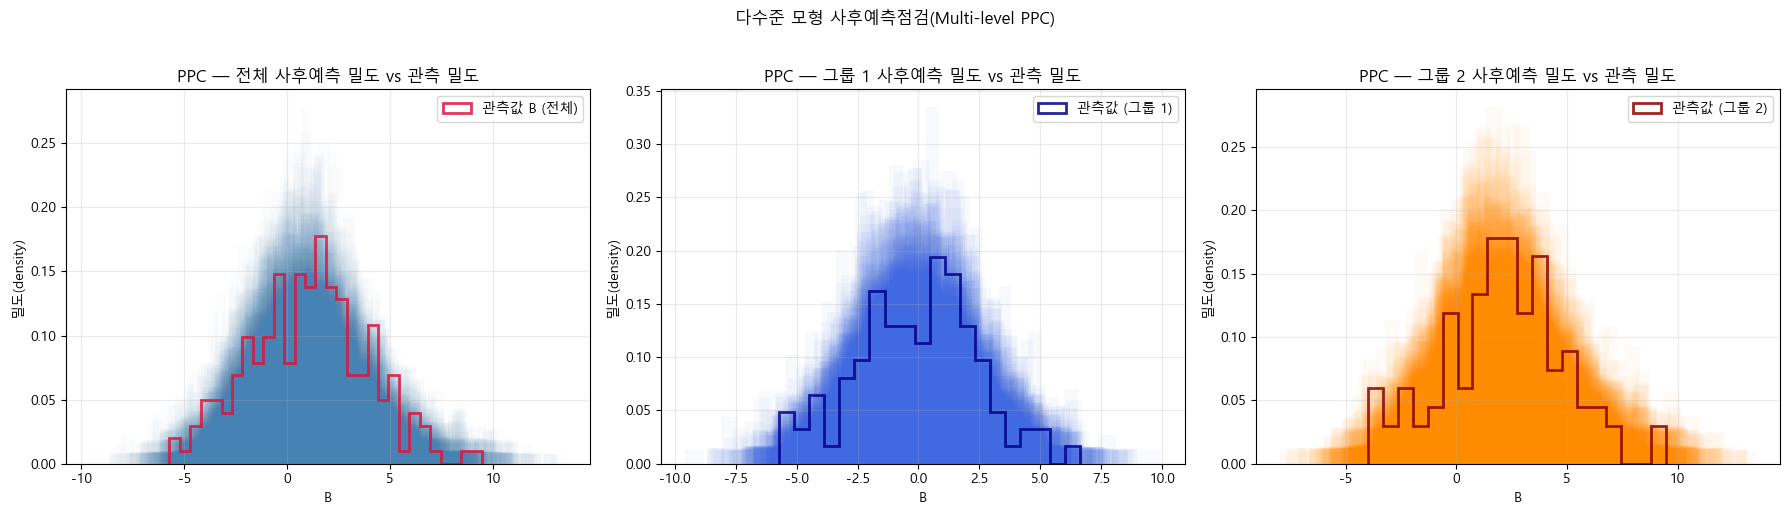

In [12]:

# 다수준 모형 사후예측점검(Posterior Predictive Check, PPC) — 그룹별
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

b_rep_cols_ml = [c for c in draws_ml.columns if c.startswith("B_rep")]
B_rep_ml = draws_ml[b_rep_cols_ml].values  # shape: (4000, N)

B_obs_all = df["B"].values
mask_g1 = (df["group_id"] == 1).values
mask_g2 = (df["group_id"] == 2).values
B_obs_g1 = B_obs_all[mask_g1]
B_obs_g2 = B_obs_all[mask_g2]

n_overlay = 200
idx = np.random.choice(B_rep_ml.shape[0], n_overlay, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 왼쪽: 전체 사후예측 밀도 vs 관측 밀도
ax = axes[0]
for i in idx:
    ax.hist(B_rep_ml[i], bins=30, density=True,
            color="steelblue", alpha=0.02, histtype="stepfilled")
ax.hist(B_obs_all, bins=30, density=True,
        color="crimson", alpha=0.85, histtype="step",
        linewidth=2, label="관측값 B (전체)")
ax.set_title("PPC — 전체 사후예측 밀도 vs 관측 밀도")
ax.set_xlabel("B")
ax.set_ylabel("밀도(density)")
ax.legend()
ax.grid(alpha=0.25)

# ── 가운데: 그룹 1 사후예측 밀도 vs 관측 밀도
ax2 = axes[1]
for i in idx:
    ax2.hist(B_rep_ml[i][mask_g1], bins=20, density=True,
             color="royalblue", alpha=0.04, histtype="stepfilled")
ax2.hist(B_obs_g1, bins=20, density=True,
         color="darkblue", alpha=0.85, histtype="step",
         linewidth=2, label="관측값 (그룹 1)")
ax2.set_title("PPC — 그룹 1 사후예측 밀도 vs 관측 밀도")
ax2.set_xlabel("B")
ax2.set_ylabel("밀도(density)")
ax2.legend()
ax2.grid(alpha=0.25)

# ── 오른쪽: 그룹 2 사후예측 밀도 vs 관측 밀도
ax3 = axes[2]
for i in idx:
    ax3.hist(B_rep_ml[i][mask_g2], bins=20, density=True,
             color="darkorange", alpha=0.04, histtype="stepfilled")
ax3.hist(B_obs_g2, bins=20, density=True,
         color="darkred", alpha=0.85, histtype="step",
         linewidth=2, label="관측값 (그룹 2)")
ax3.set_title("PPC — 그룹 2 사후예측 밀도 vs 관측 밀도")
ax3.set_xlabel("B")
ax3.set_ylabel("밀도(density)")
ax3.legend()
ax3.grid(alpha=0.25)

plt.suptitle("다수준 모형 사후예측점검(Multi-level PPC)", y=1.02)
plt.tight_layout()
plt.show()


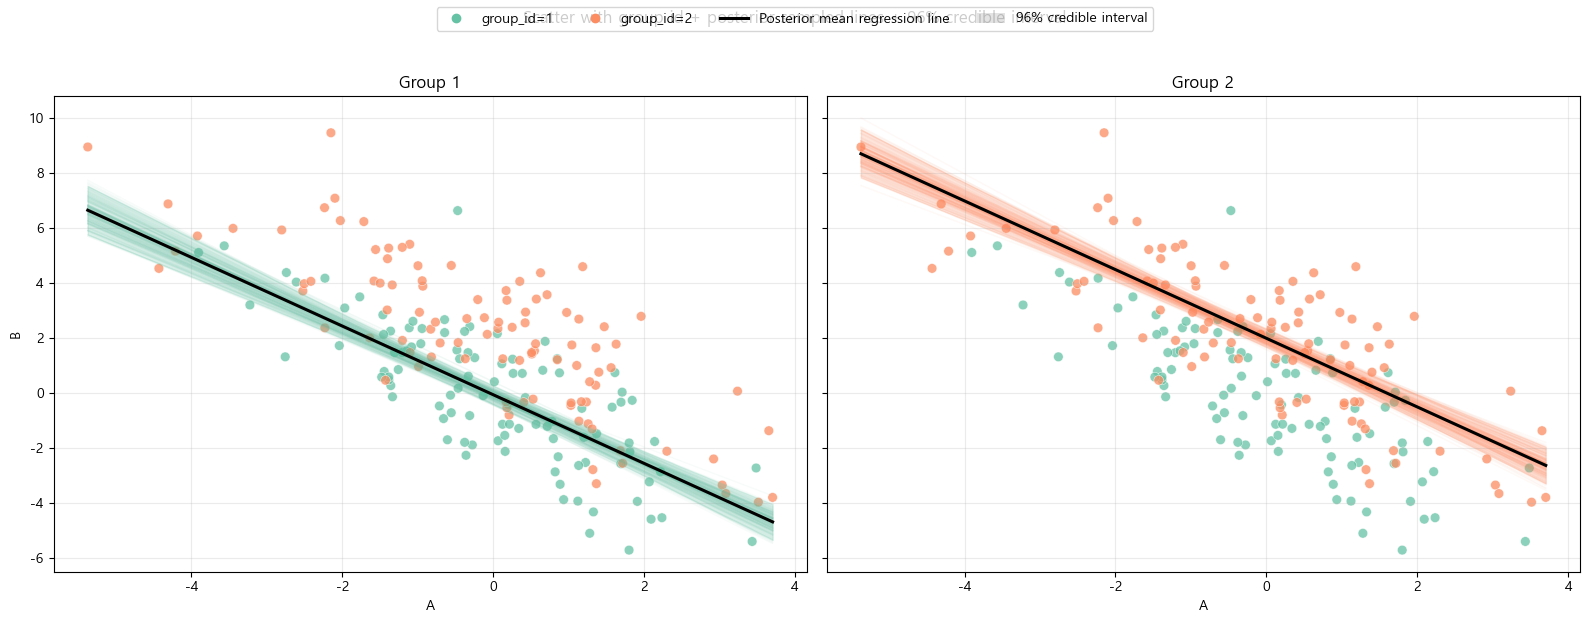

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

x_col = "A"
y_col = "B"
group_col = "group_id"

if "draws_ml" not in globals():
    raise RuntimeError("draws_ml이 없습니다. 다수준 베이지안 추정 셀을 먼저 실행하세요.")

unique_groups = sorted(df[group_col].unique())
requested_groups = [0, 1]

# Map requested groups (0,1) to actual group ids in data when needed.
if set(requested_groups).issubset(set(unique_groups)):
    requested_to_actual = {0: 0, 1: 1}
elif set([1, 2]).issubset(set(unique_groups)):
    requested_to_actual = {0: 1, 1: 2}
else:
    requested_to_actual = {
        req: unique_groups[min(i, len(unique_groups) - 1)]
        for i, req in enumerate(requested_groups)
    }

palette = sns.color_palette("Set2", n_colors=len(unique_groups))
color_map = dict(zip(unique_groups, palette))

beta_samples = draws_ml["beta"].values
x_grid = np.linspace(df[x_col].min(), df[x_col].max(), 250)

# Resolve alpha column robustly across different group codings.
def alpha_col_for_group(actual_gid, sorted_groups):
    direct_col = f"alpha[{int(actual_gid)}]"
    if direct_col in draws_ml.columns:
        return direct_col

    ordinal_col = f"alpha[{sorted_groups.index(actual_gid) + 1}]"
    if ordinal_col in draws_ml.columns:
        return ordinal_col

    raise KeyError(f"draws_ml에서 그룹 {actual_gid}에 해당하는 alpha 컬럼을 찾지 못했습니다.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

for ax, req_gid in zip(axes, requested_groups):
    actual_gid = requested_to_actual[req_gid]

    # Scatter with group id colors
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=group_col,
        palette=color_map,
        s=48,
        alpha=0.75,
        edgecolor="white",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    alpha_col = alpha_col_for_group(actual_gid, unique_groups)
    alpha_samples = draws_ml[alpha_col].values

    # Posterior sampled regression lines for selected group
    n_overlay = min(180, len(alpha_samples))
    draw_idx = np.random.choice(len(alpha_samples), size=n_overlay, replace=False)
    for i in draw_idx:
        y_line = alpha_samples[i] + beta_samples[i] * x_grid
        ax.plot(x_grid, y_line, color=color_map[actual_gid], alpha=0.05, linewidth=1)

    # 96% credible interval for E[B|A, group]
    y_grid_draws = alpha_samples[:, None] + beta_samples[:, None] * x_grid[None, :]
    y_mean = y_grid_draws.mean(axis=0)
    y_lo, y_hi = np.percentile(y_grid_draws, [2, 98], axis=0)

    ax.plot(x_grid, y_mean, color="black", linewidth=2.2)
    ax.fill_between(x_grid, y_lo, y_hi, color=color_map[actual_gid], alpha=0.22)

    ax.set_title(f"Group {actual_gid}")
    ax.set_xlabel(x_col)
    ax.grid(alpha=0.25)

axes[0].set_ylabel(y_col)

handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color_map[g], label=f"group_id={g}")
    for g in unique_groups
]
handles += [
    plt.Line2D([0], [0], color="black", linewidth=2.2, label="Posterior mean regression line"),
    plt.Rectangle((0, 0), 1, 1, facecolor="gray", alpha=0.22, label="96% credible interval"),
]
fig.legend(handles=handles, loc="upper center", ncol=min(4, len(handles)), frameon=True)
fig.suptitle("Scatter with group id + posterior sampled lines + 96% credible interval", y=1.03)
plt.tight_layout()
plt.show()

## 다수준 베이지안 추정 결과 해석

### 1) 수렴 진단(Convergence Diagnostics)

모든 모수의 $\hat{R} \approx 1.00$이며, ESS(유효표본수, effective sample size)도 충분히 크게 나타났습니다. 이는 4개의 MCMC 체인이 동일한 사후분포(posterior distribution)에 수렴했음을 의미하며, 추정 결과를 신뢰할 수 있습니다.

---

### 2) 초모수(Hyperparameters): $\mu_\alpha$와 $\tau$

| 모수 | 사후평균 | 96% CI |
|------|---------|--------|
| $\mu_\alpha$ (절편 모집단 평균) | 0.940 | [-1.920, 3.522] |
| $\tau$ (그룹 간 절편 표준편차) | 1.580 | [0.578, 3.871] |

- $\mu_\alpha$의 96% 신뢰구간이 넓은 것은 그룹 수가 **G=2**로 매우 적기 때문입니다. 그룹이 2개뿐이면 모집단 평균(population mean)을 정밀하게 추정하기 어렵습니다.
- $\tau \approx 1.58$는 그룹 간 절편 차이의 표준편차(standard deviation)를 뜻합니다. 실제 두 그룹 절편 차이가 약 2.06이므로, 이 값과 일관성이 있습니다.

---

### 3) 그룹별 절편(Group-specific Intercepts): $\alpha_1$, $\alpha_2$

| 모수 | 사후평균 | 96% CI | OLS 비교 |
|------|---------|--------|---------|
| $\alpha_1$ (그룹 1 절편) | -0.062 | [-0.406, 0.271] | -0.085 |
| $\alpha_2$ (그룹 2 절편) | 1.994 | [1.674, 2.328] | 2.016 |

- 두 절편의 사후평균 차이 $\alpha_2 - \alpha_1 \approx 2.056$으로, 데이터 생성 시 설정한 이동량(shift) $[0, 2]$와 잘 일치합니다.
- $\alpha_1$의 96% CI는 0을 포함하고, $\alpha_2$의 CI는 전부 양수입니다. 즉 그룹 2의 절편은 그룹 1보다 통계적으로 유의하게 큽니다.
- **부분 풀링(partial pooling) 효과**: Bayesian 추정값이 OLS 추정값과 매우 유사합니다. 그룹 내 데이터(각각 100개)가 충분하므로 shrinkage 효과가 작게 나타납니다. 데이터가 적을수록 두 절편은 $\mu_\alpha$ 쪽으로 더 강하게 수축(shrink)됩니다.

---

### 4) 공통 기울기(Common Slope): $\beta$

| 모수 | 사후평균 | 96% CI | OLS(pooled) 비교 |
|------|---------|--------|---------|
| $\beta$ (공통 기울기) | -1.251 | [-1.403, -1.097] | -1.268 |

- $\beta < 0$이므로 $A$가 증가할수록 $B$는 평균적으로 감소합니다.
- 96% CI 전체가 음수이므로, 이 음의 관계(negative relationship)는 통계적으로 신뢰할 수 있습니다.
- 데이터 생성 시 30° 회전을 적용했기 때문에 음의 기울기가 나타납니다.

---

### 5) 잔차 표준편차(Residual Standard Deviation): $\sigma$

| 모형 | $\sigma$ 사후평균 |
|------|---------|
| **그룹 무시 (pooled)** Bayesian | 1.965 |
| **다수준 (multi-level)** Bayesian | **1.666** |

- 그룹 구조를 반영하자 $\sigma$가 1.965 → 1.666으로 약 **15% 감소**했습니다.
- 이는 절편 차이(~2.06)에 해당하는 분산이 $\sigma$에서 분리되어 $\alpha_g$로 흡수된 결과입니다.
- PPC 결과에서도 다수준 모형이 그룹별 밀도를 훨씬 잘 재현하는 것이 확인됩니다.

---

### 6) 종합 해석

> 다수준 모형은 그룹 간 절편 차이를 명시적으로 모형화하여, 잔차 분산을 줄이고 그룹별 데이터 분포를 더 충실히 재현합니다. 두 그룹의 데이터 양이 충분하므로 부분 풀링의 shrinkage 효과는 작고 OLS 추정값과 거의 일치하지만, 사후분포(posterior distribution)를 통해 **모수 불확실성(parameter uncertainty)**을 정량적으로 파악할 수 있다는 점이 Bayesian 접근의 핵심 강점입니다.


## Multi-Level Bayesian Inference



In [ ]:
# 다수준 Stan 모델: 그룹별 절편(alpha_g) + 그룹별 기울기(beta_g)
import pathlib
from cmdstanpy import CmdStanModel

stan_hier_slope_intercept_code = """
data {
  int<lower=1> N;
  int<lower=1> G;
  array[N] int<lower=1, upper=G> group_id;
  vector[N] A;
  vector[N] B;
}
parameters {
  real mu_alpha;
  real<lower=0> sigma_alpha;
  vector[G] alpha_raw;

  real mu_beta;
  real<lower=0> sigma_beta;
  vector[G] beta_raw;

  real<lower=0> sigma;
}
transformed parameters {
  vector[G] alpha;
  vector[G] beta;

  alpha = mu_alpha + sigma_alpha * alpha_raw;
  beta  = mu_beta  + sigma_beta  * beta_raw;
}
model {
  // Hyper-priors
  mu_alpha ~ normal(0, 10);
  sigma_alpha ~ exponential(1);

  mu_beta ~ normal(0, 10);
  sigma_beta ~ exponential(1);

  sigma ~ exponential(1);

  // Non-centered priors
  alpha_raw ~ normal(0, 1);
  beta_raw ~ normal(0, 1);

  // Likelihood
  for (n in 1:N) {
    B[n] ~ normal(alpha[group_id[n]] + beta[group_id[n]] * A[n], sigma);
  }
}
generated quantities {
  vector[N] B_rep;
  for (n in 1:N) {
    B_rep[n] = normal_rng(alpha[group_id[n]] + beta[group_id[n]] * A[n], sigma);
  }
}
"""

stan_hier_file = pathlib.Path("multilevel_group_intercept_slope.stan")
stan_hier_file.write_text(stan_hier_slope_intercept_code)

model_hier = CmdStanModel(stan_file=str(stan_hier_file))

stan_hier_data = {
    "N": len(df),
    "G": int(df["group_id"].nunique()),
    "group_id": df["group_id"].astype(int).tolist(),
    "A": df["A"].tolist(),
    "B": df["B"].tolist(),
}

fit_hier = model_hier.sample(
    data=stan_hier_data,
    chains=2,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=42,
    show_progress=True,
)

summary_hier = fit_hier.summary()
print(summary_hier.loc[["mu_alpha", "sigma_alpha", "mu_beta", "sigma_beta", "sigma", "alpha[1]", "alpha[2]", "beta[1]", "beta[2]"]])


12:13:56 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\Downloads\KOS-5101\misc\multilevel_group_intercept_slope.stan to exe file C:\Users\yongduek\Downloads\KOS-5101\misc\multilevel_group_intercept_slope.exe
12:14:11 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\Downloads\KOS-5101\misc\multilevel_group_intercept_slope.exe
12:14:12 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

12:14:15 - cmdstanpy - INFO - CmdStan done processing.
12:14:15 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'multilevel_group_intercept_slope.stan', line 43, column 4 to column 72)
Consider re-running with show_console=True if the above output is unclear!
12:14:15 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 8 divergent transitions (0.8%)
	Chain 2 had 1 divergent transitions (0.1%)
	Chain 3 had 5 divergent transitions (0.5%)
	Chain 4 had 6 divergent transitions (0.6%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



                 Mean      MCSE    StdDev       MAD        5%       50%  \
mu_alpha     0.966027  0.042597  1.291570  0.971714 -1.049230  0.932787   
sigma_alpha  1.588000  0.022282  0.827942  0.648228  0.667610  1.370220   
mu_beta     -1.252540  0.011241  0.315238  0.159412 -1.717460 -1.253420   
sigma_beta   0.349038  0.014708  0.424311  0.215882  0.014118  0.195280   
sigma        1.666950  0.001618  0.083999  0.084659  1.537900  1.664860   
alpha[1]    -0.064179  0.002671  0.168758  0.166853 -0.336512 -0.065569   
alpha[2]     1.994130  0.002519  0.164584  0.158802  1.720480  1.995100   
beta[1]     -1.282460  0.001783  0.106079  0.102962 -1.460780 -1.277340   
beta[2]     -1.228860  0.001399  0.086758  0.086197 -1.368030 -1.230420   

                  95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
mu_alpha     3.023290  1142.200  1019.520     203.636  1.00380  
sigma_alpha  3.243150  1560.920  1390.080     278.289  1.00289  
mu_beta     -0.757105  1071.420   713.024     191.017

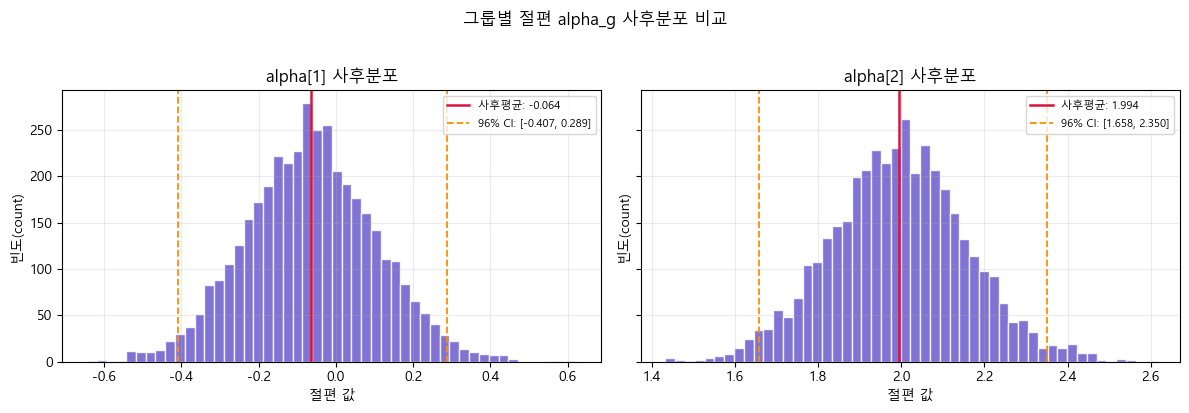

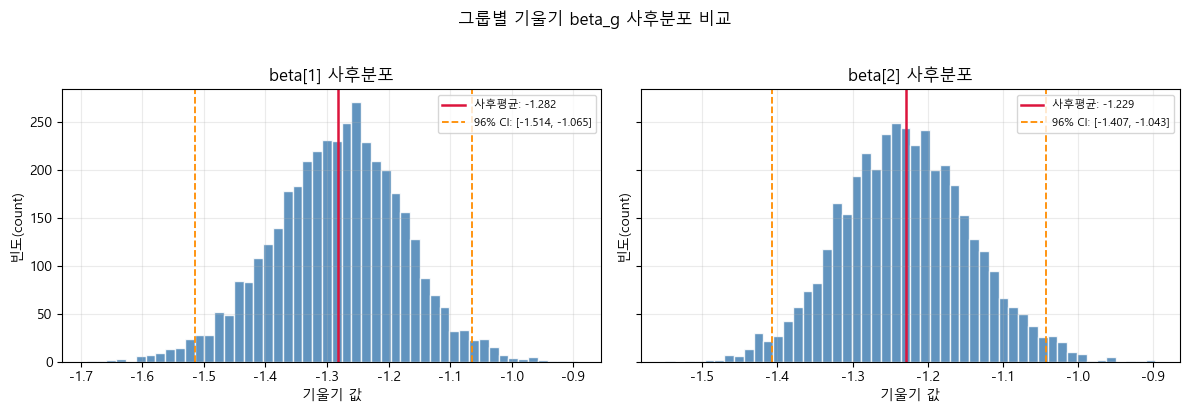

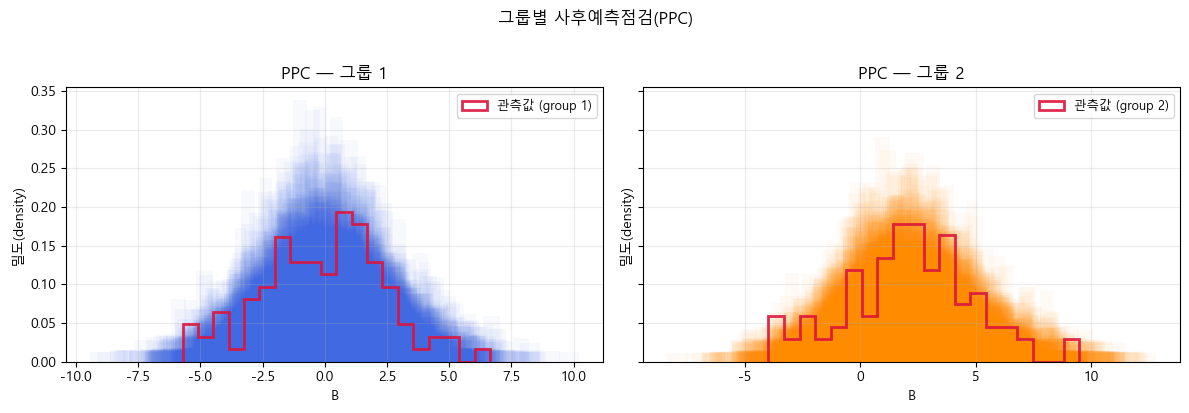

In [19]:
# fit_hier 결과 기반: 그룹별 alpha_g / beta_g 사후분포 비교 + 그룹별 PPC
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

draws_hier = fit_hier.draws_pd()
unique_groups = sorted(df["group_id"].unique())

# -----------------------------
# 1) 그룹별 alpha_g 사후분포 비교
# -----------------------------
fig, axes = plt.subplots(1, len(unique_groups), figsize=(6 * len(unique_groups), 4), sharey=True)
if len(unique_groups) == 1:
    axes = [axes]

for ax, gid in zip(axes, unique_groups):
    alpha_col = f"alpha[{int(gid)}]"
    alpha_samples = draws_hier[alpha_col].values

    lo, hi = np.percentile(alpha_samples, [2, 98])
    ax.hist(alpha_samples, bins=50, color="slateblue", edgecolor="white", alpha=0.85)
    ax.axvline(alpha_samples.mean(), color="crimson", linewidth=1.8,
               label=f"사후평균: {alpha_samples.mean():.3f}")
    ax.axvline(lo, color="darkorange", linestyle="--", linewidth=1.3,
               label=f"96% CI: [{lo:.3f}, {hi:.3f}]")
    ax.axvline(hi, color="darkorange", linestyle="--", linewidth=1.3)
    ax.set_title(f"alpha[{int(gid)}] 사후분포")
    ax.set_xlabel("절편 값")
    ax.set_ylabel("빈도(count)")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.suptitle("그룹별 절편 alpha_g 사후분포 비교", y=1.02)
plt.tight_layout()
plt.show()

# -----------------------------
# 2) 그룹별 beta_g 사후분포 비교
# -----------------------------
fig, axes = plt.subplots(1, len(unique_groups), figsize=(6 * len(unique_groups), 4), sharey=True)
if len(unique_groups) == 1:
    axes = [axes]

for ax, gid in zip(axes, unique_groups):
    beta_col = f"beta[{int(gid)}]"
    beta_samples = draws_hier[beta_col].values

    lo, hi = np.percentile(beta_samples, [2, 98])
    ax.hist(beta_samples, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(beta_samples.mean(), color="crimson", linewidth=1.8,
               label=f"사후평균: {beta_samples.mean():.3f}")
    ax.axvline(lo, color="darkorange", linestyle="--", linewidth=1.3,
               label=f"96% CI: [{lo:.3f}, {hi:.3f}]")
    ax.axvline(hi, color="darkorange", linestyle="--", linewidth=1.3)
    ax.set_title(f"beta[{int(gid)}] 사후분포")
    ax.set_xlabel("기울기 값")
    ax.set_ylabel("빈도(count)")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.suptitle("그룹별 기울기 beta_g 사후분포 비교", y=1.02)
plt.tight_layout()
plt.show()

# -----------------------------
# 3) 그룹별 PPC
# -----------------------------
b_rep_cols_hier = [c for c in draws_hier.columns if c.startswith("B_rep[")]
B_rep_hier = draws_hier[b_rep_cols_hier].values  # shape: (draws, N)
B_obs = df["B"].values

fig, axes = plt.subplots(1, len(unique_groups), figsize=(6 * len(unique_groups), 4), sharey=True)
if len(unique_groups) == 1:
    axes = [axes]

n_overlay = min(200, B_rep_hier.shape[0])
overlay_idx = np.random.choice(B_rep_hier.shape[0], size=n_overlay, replace=False)
colors = ["royalblue", "darkorange", "seagreen", "purple", "brown"]

for j, (ax, gid) in enumerate(zip(axes, unique_groups)):
    mask = (df["group_id"] == gid).values
    B_obs_g = B_obs[mask]

    for i in overlay_idx:
        ax.hist(B_rep_hier[i][mask], bins=20, density=True,
                color=colors[j % len(colors)], alpha=0.035, histtype="stepfilled")

    ax.hist(B_obs_g, bins=20, density=True,
            color="crimson", alpha=0.9, histtype="step", linewidth=2,
            label=f"관측값 (group {gid})")
    ax.set_title(f"PPC — 그룹 {gid}")
    ax.set_xlabel("B")
    ax.set_ylabel("밀도(density)")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

plt.suptitle("그룹별 사후예측점검(PPC)", y=1.02)
plt.tight_layout()
plt.show()


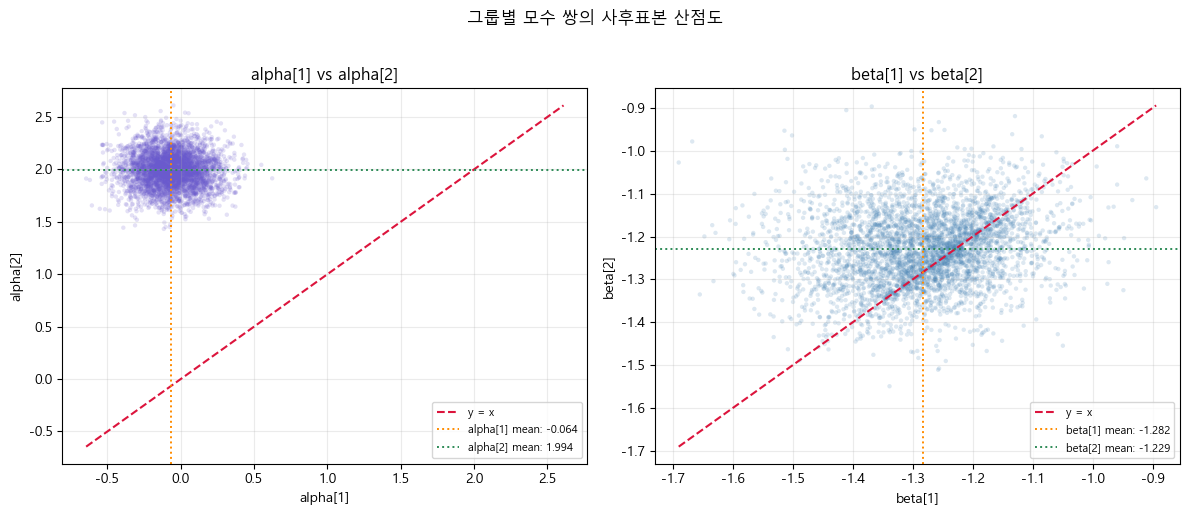

In [ ]:
# Posterior sample scatter plots: (alpha[1], alpha[2]) and (beta[1], beta[2])
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

if "draws_hier" not in globals():
    draws_hier = fit_hier.draws_pd()

alpha_1 = draws_hier["alpha[1]"].values
alpha_2 = draws_hier["alpha[2]"].values
beta_1 = draws_hier["beta[1]"].values
beta_2 = draws_hier["beta[2]"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pairs = [
    (axes[0], alpha_1, alpha_2, "alpha[1] vs alpha[2]", "alpha[1]", "alpha[2]", "slateblue"),
    (axes[1], beta_1, beta_2, "beta[1] vs beta[2]", "beta[1]", "beta[2]", "steelblue"),
]

for ax, x_samples, y_samples, title, xlabel, ylabel, color in pairs:
    ax.scatter(x_samples, y_samples, s=10, alpha=0.18, color=color, edgecolors="none")

    xy_min = min(x_samples.min(), y_samples.min())
    xy_max = max(x_samples.max(), y_samples.max())
    ax.plot([xy_min, xy_max], [xy_min, xy_max], color="crimson", linestyle="--", linewidth=1.5, label="y = x")

    ax.axvline(x_samples.mean(), color="darkorange", linestyle=":", linewidth=1.4,
               label=f"{xlabel} mean: {x_samples.mean():.3f}")
    ax.axhline(y_samples.mean(), color="seagreen", linestyle=":", linewidth=1.4,
               label=f"{ylabel} mean: {y_samples.mean():.3f}")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.suptitle("그룹별 모수 쌍의 사후표본 산점도", y=1.02)
plt.tight_layout()
plt.show()

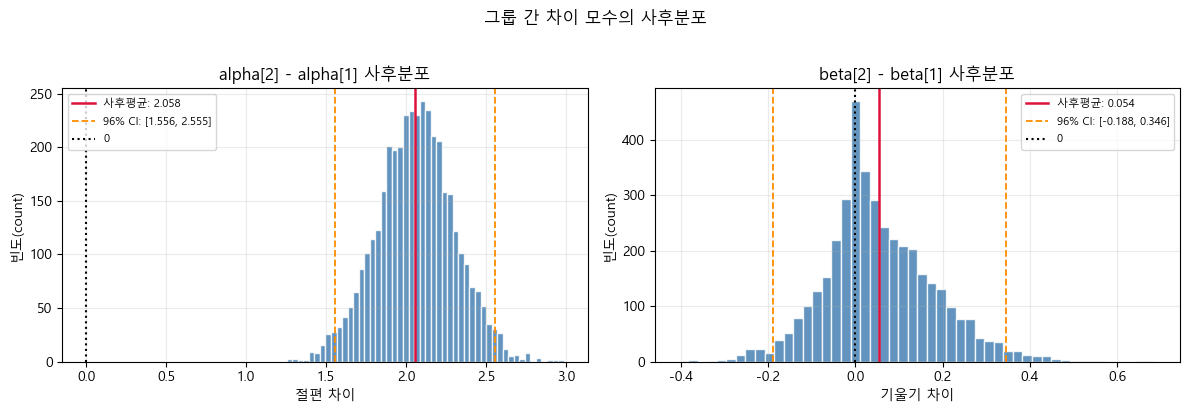

In [ ]:
# 차이 모수의 사후분포: alpha[2]-alpha[1], beta[2]-beta[1]
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

if "draws_hier" not in globals():
    draws_hier = fit_hier.draws_pd()

alpha_diff = draws_hier["alpha[2]"].values - draws_hier["alpha[1]"].values
beta_diff = draws_hier["beta[2]"].values - draws_hier["beta[1]"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, samples, title, xlabel in [
    (axes[0], alpha_diff, "alpha[2] - alpha[1] 사후분포", "절편 차이"),
    (axes[1], beta_diff, "beta[2] - beta[1] 사후분포", "기울기 차이"),
]:
    lo, hi = np.percentile(samples, [2, 98])
    ax.hist(samples, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(samples.mean(), color="crimson", linewidth=1.8,
               label=f"사후평균: {samples.mean():.3f}")
    ax.axvline(lo, color="darkorange", linestyle="--", linewidth=1.3,
               label=f"96% CI: [{lo:.3f}, {hi:.3f}]")
    ax.axvline(hi, color="darkorange", linestyle="--", linewidth=1.3)
    ax.axvline(0, color="black", linestyle=":", linewidth=1.5, label="0")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("빈도(count)")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.suptitle("그룹 간 차이 모수의 사후분포", y=1.02)
plt.tight_layout()
plt.show()



In [21]:
# Posterior probabilities: Prob[a2 - a1 > 0], Prob[b2 - b1 > 0]
if "alpha_diff" not in globals() or "beta_diff" not in globals():
    if "draws_hier" not in globals():
        draws_hier = fit_hier.draws_pd()
    alpha_diff = draws_hier["alpha[2]"].values - draws_hier["alpha[1]"].values
    beta_diff = draws_hier["beta[2]"].values - draws_hier["beta[1]"].values

prob_alpha_diff_gt_0 = np.mean(alpha_diff > 0)
prob_beta_diff_gt_0 = np.mean(beta_diff > 0)

print(f"Prob[a2 - a1 > 0] = {prob_alpha_diff_gt_0:.4f}")
print(f"Prob[b2 - b1 > 0] = {prob_beta_diff_gt_0:.4f}")


Prob[a2 - a1 > 0] = 1.0000
Prob[b2 - b1 > 0] = 0.6530


## How to choose among the three Bayesian models

이 노트북의 Bayesian 모형은 다음 세 가지이다.

1. **Pooled Bayesian regression**  
   $$
   B_i = \beta_0 + \beta_1 A_i + \varepsilon_i
   $$

2. **Multi-level model with group-specific intercepts and common slope**  
   $$
   B_i = \alpha_{g[i]} + \beta A_i + \varepsilon_i
   $$

3. **Multi-level model with group-specific intercepts and group-specific slopes**  
   $$
   B_i = \alpha_{g[i]} + \beta_{g[i]} A_i + \varepsilon_i
   $$

적절한 모형을 고를 때는, 단순히 "더 복잡한 모형"을 고르기보다 아래 순서로 판단하는 것이 좋다.

### 1) 먼저 데이터 생성 가정 또는 도메인 가정을 본다

- 그룹 차이가 전혀 없다고 믿는다면 pooled model이 가장 단순하고 해석도 쉽다.
- 그룹마다 평균 수준은 다르지만, $A$와 $B$의 관계 기울기는 같다고 보면 공통 기울기 다수준 모형이 자연스럽다.
- 그룹마다 평균도 다르고, $A$가 $B$에 미치는 정도 자체도 다르다고 보면 그룹별 절편 + 그룹별 기울기 모형이 필요하다.

즉, **모형 선택의 첫 기준은 "그룹 차이가 절편 차이만인가, 아니면 기울기 차이까지 포함하는가"** 이다.

### 2) 그다음 posterior predictive check(PPC)를 비교한다

- pooled model의 PPC가 그룹별 분포를 잘 재현하지 못하면, 그룹 구조를 무시한 것이므로 더 복잡한 모형으로 가야 한다.
- 공통 기울기 다수준 모형의 PPC가 이미 각 그룹을 충분히 잘 설명한다면, 굳이 그룹별 기울기까지 넣지 않아도 된다.
- 그룹별 기울기 모형이 PPC를 눈에 띄게 개선한다면, slope 차이를 허용하는 것이 타당하다.

실무적으로는 **가장 단순한 모형부터 시작해서 PPC가 어디서 실패하는지** 보는 방식이 안정적이다.

### 3) 차이 모수의 posterior를 본다

- $\alpha_2 - \alpha_1$의 posterior가 분명히 0에서 멀면, 그룹 간 절편 차이가 있다는 뜻이다.
- $\beta_2 - \beta_1$의 posterior가 0 근처에 넓게 걸쳐 있으면, 그룹별 slope를 따로 둘 근거는 약하다.
- 반대로 $P(\beta_2 - \beta_1 > 0)$ 또는 $P(\beta_2 - \beta_1 < 0)$가 매우 크고, difference posterior도 0에서 충분히 떨어져 있으면 slope 차이를 허용한 모형이 더 설득력 있다.

즉, **추가된 모수(group-specific slope)가 실제로 필요한지 posterior difference로 확인**해야 한다.

### 4) 예측 성능 기준을 함께 쓴다

가능하면 다음과 같은 Bayesian model comparison 기준을 같이 본다.

- LOO-CV (leave-one-out cross-validation)
- WAIC
- out-of-sample predictive performance

이 지표들은 "복잡한 모형이 훈련 데이터에만 더 잘 맞는 것인지", 아니면 실제 예측력도 좋아지는지 판단하는 데 유용하다.

### 5) 해석 가능성과 데이터 크기를 함께 고려한다

- 데이터가 적고 그룹 수도 적으면, 그룹별 slope까지 넣은 모형은 불확실성이 매우 커질 수 있다.
- 이 경우 공통 기울기 다수준 모형이 더 안정적이고 해석도 쉽다.
- 데이터가 충분하고 그룹별 slope 차이가 실제로 중요하면, 가장 풍부한 hierarchical slope model이 적절하다.

즉, **복잡한 모형은 더 유연하지만, 그만큼 더 많은 데이터와 더 강한 근거가 필요하다.**

### Practical rule of thumb

1. 먼저 pooled model에 대하여 추정한다.
2. 그룹 구조가 보이면 공통 기울기 다수준 모형으로 올라간다.
3. slope 차이까지 필요해 보일 때만 그룹별 slope 모형으로 확장한다.
4. 최종 선택은 PPC, difference posterior, 그리고 가능하면 LOO/WAIC를 함께 보고 결정한다.

이 노트북의 현재 결과를 기준으로 보면,

- pooled model은 그룹 구조를 무시하므로 가장 덜 적절하다.
- 공통 기울기 다수준 모형은 절편 차이를 잘 반영하면서 비교적 단순하다.
- 그룹별 slope 모형은 가장 유연하지만, $\beta_2 - \beta_1$에 대한 posterior evidence가 강하지 않다면 "반드시 필요하다"고 말하기는 어렵다.

따라서 현재 예시에서는 **"절편 차이는 분명하지만 slope 차이는 약하다"** 라면, 공통 기울기 다수준 모형이 좋은 기본 선택이고, slope 차이까지 강하게 주장하려면 group-specific slope model에 대한 추가 근거가 필요하다.

In [24]:
# Bayesian model comparison for the three fitted models: pooled, multilevel(common slope), hierarchical(group slope)
import numpy as np
import pandas as pd

y_obs = df["B"].to_numpy()
a_obs = df["A"].to_numpy()
g_idx = df["group_id"].astype(int).to_numpy() - 1  # zero-based index

if "draws" not in globals():
    draws = fit.draws_pd()
if "draws_ml" not in globals():
    draws_ml = fit_ml.draws_pd()
if "draws_hier" not in globals():
    draws_hier = fit_hier.draws_pd()

def normal_logpdf(y, mu, sigma):
    return -0.5 * np.log(2 * np.pi) - np.log(sigma) - 0.5 * ((y - mu) / sigma) ** 2

def stable_logmeanexp(values, axis=0):
    max_val = np.max(values, axis=axis, keepdims=True)
    return np.squeeze(max_val, axis=axis) + np.log(np.mean(np.exp(values - max_val), axis=axis))

def compute_waic(log_lik):
    lppd_i = stable_logmeanexp(log_lik, axis=0)
    p_waic_i = np.var(log_lik, axis=0, ddof=1)
    elpd_waic = np.sum(lppd_i - p_waic_i)
    waic = -2 * elpd_waic
    return {
        "lppd": float(np.sum(lppd_i)),
        "p_waic": float(np.sum(p_waic_i)),
        "elpd_waic": float(elpd_waic),
        "waic": float(waic),
    }

def compute_dic(log_lik, mu_hat):
    deviance_draws = -2 * np.sum(log_lik, axis=1)
    d_bar = float(np.mean(deviance_draws))
    d_hat = float(-2 * np.sum(normal_logpdf(y_obs, mu_hat["mean"], mu_hat["sigma"])))
    p_dic = d_bar - d_hat
    dic = d_bar + p_dic
    return {
        "d_bar": d_bar,
        "d_hat": d_hat,
        "p_dic": float(p_dic),
        "dic": float(dic),
    }

def compute_predictive_errors(y, mu_draws):
    pred_mean = mu_draws.mean(axis=0)
    rmse = float(np.sqrt(np.mean((y - pred_mean) ** 2)))
    mae = float(np.mean(np.abs(y - pred_mean)))
    return {
        "rmse": rmse,
        "mae": mae,
    }

def pooled_quantities(draws_df):
    beta0 = draws_df["beta0"].to_numpy()[:, None]
    beta1 = draws_df["beta1"].to_numpy()[:, None]
    sigma = draws_df["sigma"].to_numpy()[:, None]
    mu_draws = beta0 + beta1 * a_obs[None, :]
    log_lik = normal_logpdf(y_obs[None, :], mu_draws, sigma)
    mu_hat = {
        "mean": draws_df["beta0"].mean() + draws_df["beta1"].mean() * a_obs,
        "sigma": float(draws_df["sigma"].mean()),
    }
    return mu_draws, log_lik, mu_hat

def common_slope_quantities(draws_df):
    alpha_1 = draws_df["alpha[1]"].to_numpy()
    alpha_2 = draws_df["alpha[2]"].to_numpy()
    beta = draws_df["beta"].to_numpy()
    sigma = draws_df["sigma"].to_numpy()[:, None]

    alpha_mat = np.column_stack([alpha_1, alpha_2])
    mu_draws = alpha_mat[:, g_idx] + beta[:, None] * a_obs[None, :]
    log_lik = normal_logpdf(y_obs[None, :], mu_draws, sigma)
    mu_hat = {
        "mean": np.where(g_idx == 0, alpha_1.mean(), alpha_2.mean()) + beta.mean() * a_obs,
        "sigma": float(draws_df["sigma"].mean()),
    }
    return mu_draws, log_lik, mu_hat

def group_slope_quantities(draws_df):
    alpha_1 = draws_df["alpha[1]"].to_numpy()
    alpha_2 = draws_df["alpha[2]"].to_numpy()
    beta_1 = draws_df["beta[1]"].to_numpy()
    beta_2 = draws_df["beta[2]"].to_numpy()
    sigma = draws_df["sigma"].to_numpy()[:, None]

    alpha_mat = np.column_stack([alpha_1, alpha_2])
    beta_mat = np.column_stack([beta_1, beta_2])
    mu_draws = alpha_mat[:, g_idx] + beta_mat[:, g_idx] * a_obs[None, :]
    log_lik = normal_logpdf(y_obs[None, :], mu_draws, sigma)
    mu_hat = {
        "mean": np.where(g_idx == 0, alpha_1.mean(), alpha_2.mean()) + np.where(g_idx == 0, beta_1.mean(), beta_2.mean()) * a_obs,
        "sigma": float(draws_df["sigma"].mean()),
    }
    return mu_draws, log_lik, mu_hat

model_specs = {
    "Pooled Bayesian": {"builder": lambda: pooled_quantities(draws), "chains": 4},
    "Multi-level (common slope)": {"builder": lambda: common_slope_quantities(draws_ml), "chains": 4},
    "Multi-level (group intercept + slope)": {"builder": lambda: group_slope_quantities(draws_hier), "chains": 2},
}

comparison_rows = []
stored_log_lik = {}

for model_name, spec in model_specs.items():
    mu_draws, log_lik, mu_hat = spec["builder"]()
    stored_log_lik[model_name] = {"log_lik": log_lik, "chains": spec["chains"]}

    waic_stats = compute_waic(log_lik)
    dic_stats = compute_dic(log_lik, mu_hat)
    error_stats = compute_predictive_errors(y_obs, mu_draws)
    mean_loglik = float(np.mean(np.sum(log_lik, axis=1)))

    comparison_rows.append({
        "model": model_name,
        "WAIC": waic_stats["waic"],
        "elpd_WAIC": waic_stats["elpd_waic"],
        "p_WAIC": waic_stats["p_waic"],
        "DIC": dic_stats["dic"],
        "p_DIC": dic_stats["p_dic"],
        "mean_loglik": mean_loglik,
        "RMSE(mean prediction)": error_stats["rmse"],
        "MAE(mean prediction)": error_stats["mae"],
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("WAIC").reset_index(drop=True)

print("Bayesian model comparison summary")
display(comparison_df.style.format({
    "WAIC": "{:.2f}",
    "elpd_WAIC": "{:.2f}",
    "p_WAIC": "{:.2f}",
    "DIC": "{:.2f}",
    "p_DIC": "{:.2f}",
    "mean_loglik": "{:.2f}",
    "RMSE(mean prediction)": "{:.3f}",
    "MAE(mean prediction)": "{:.3f}",
}))

best_waic_model = comparison_df.loc[0, "model"]
best_dic_model = comparison_df.sort_values("DIC").iloc[0]["model"]
best_rmse_model = comparison_df.sort_values("RMSE(mean prediction)").iloc[0]["model"]

print(f"\nBest by WAIC: {best_waic_model}")
print(f"Best by DIC: {best_dic_model}")
print(f"Best by RMSE of posterior mean prediction: {best_rmse_model}")

print("\nInterpretation guide")
print("- WAIC, DIC: smaller is better")
print("- elpd_WAIC, mean_loglik: larger is better")
print("- RMSE, MAE: smaller is better")

# Optional: PSIS-LOO with ArviZ if available
try:
    import arviz as az

    loo_rows = []
    for model_name, info in stored_log_lik.items():
        log_lik = info["log_lik"]
        chains = info["chains"]
        draws_per_chain = log_lik.shape[0] // chains
        log_lik_3d = log_lik.reshape(chains, draws_per_chain, log_lik.shape[1])
        fake_posterior = np.zeros((chains, draws_per_chain, 1))
        idata = az.from_dict(
            posterior={"dummy": fake_posterior},
            log_likelihood={"y": log_lik_3d},
        )
        loo_result = az.loo(idata, var_name="y", pointwise=False)
        loo_rows.append({
            "model": model_name,
            "elpd_LOO": float(loo_result.elpd_loo),
            "p_LOO": float(loo_result.p_loo),
            "LOOIC": float(-2 * loo_result.elpd_loo),
        })

    loo_df = pd.DataFrame(loo_rows).sort_values("LOOIC").reset_index(drop=True)
    print("\nPSIS-LOO summary")
    display(loo_df.style.format({
        "elpd_LOO": "{:.2f}",
        "p_LOO": "{:.2f}",
        "LOOIC": "{:.2f}",
    }))
    print(f"Best by PSIS-LOO: {loo_df.loc[0, 'model']}")
except Exception as exc:
    print("\nPSIS-LOO는 ArviZ가 없거나 입력 형식이 맞지 않아 건너뜁니다.")
    print(f"Reason: {type(exc).__name__}: {exc}")

Bayesian model comparison summary


,model,WAIC,elpd_WAIC,p_WAIC,DIC,p_DIC,mean_loglik,RMSE(mean prediction),MAE(mean prediction)
0,Multi-level (common slope),776.00,-388.00,3.96,775.89,3.96,-385.97,1.650,1.356
1,Multi-level (group intercept + slope),777.04,-388.52,4.55,777.04,4.68,-386.18,1.649,1.354
2,Pooled Bayesian,841.52,-420.76,2.76,841.72,3.02,-419.35,1.955,1.558



Best by WAIC: Multi-level (common slope)
Best by DIC: Multi-level (common slope)
Best by RMSE of posterior mean prediction: Multi-level (group intercept + slope)

Interpretation guide
- WAIC, DIC: smaller is better
- elpd_WAIC, mean_loglik: larger is better
- RMSE, MAE: smaller is better

PSIS-LOO summary


,model,elpd_LOO,p_LOO,LOOIC
0,Multi-level (common slope),-388.01,3.97,776.02
1,Multi-level (group intercept + slope),-388.53,4.56,777.06
2,Pooled Bayesian,-420.77,2.77,841.53


Best by PSIS-LOO: Multi-level (common slope)


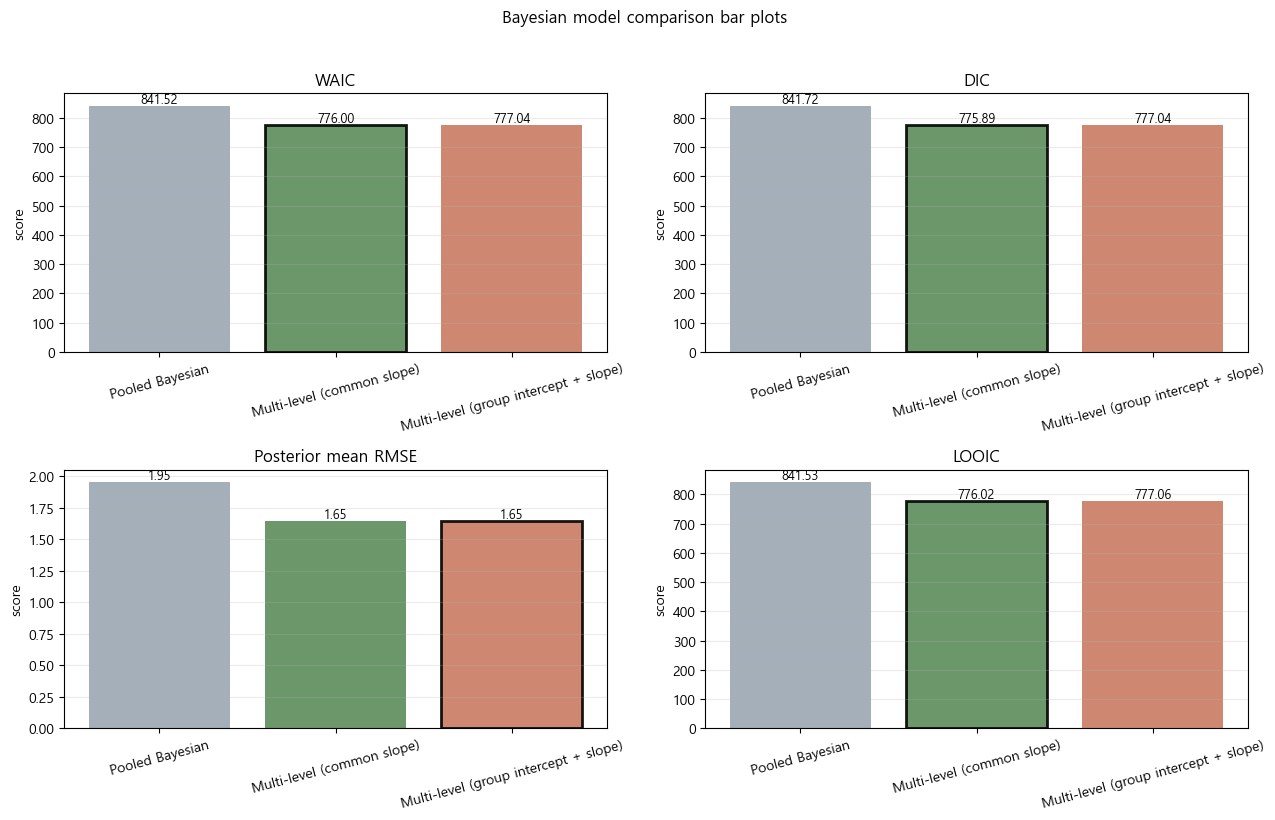

In [25]:
# Visualize Bayesian model comparison results with bar plots
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

if "comparison_df" not in globals():
    raise RuntimeError("comparison_df가 없습니다. 바로 위 모델 비교 셀을 먼저 실행하세요.")

plot_df = comparison_df.copy()
plot_df = plot_df.set_index("model").loc[[
    "Pooled Bayesian",
    "Multi-level (common slope)",
    "Multi-level (group intercept + slope)",
]].reset_index()

metrics = [
    ("WAIC", "WAIC", True),
    ("DIC", "DIC", True),
    ("RMSE(mean prediction)", "Posterior mean RMSE", True),
]

if "loo_df" in globals():
    loo_map = loo_df.set_index("model")["LOOIC"]
    plot_df["LOOIC"] = plot_df["model"].map(loo_map)
    metrics.append(("LOOIC", "LOOIC", True))

colors = ["#9aa6b2", "#5b8c5a", "#c97b63"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for ax, (column, title, lower_is_better) in zip(axes, metrics):
    values = plot_df[column].to_numpy()
    bars = ax.bar(plot_df["model"], values, color=colors, alpha=0.9)
    best_idx = int(np.argmin(values) if lower_is_better else np.argmax(values))
    bars[best_idx].set_edgecolor("black")
    bars[best_idx].set_linewidth(2.0)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_title(title)
    ax.set_ylabel("score")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=15)

for ax in axes[len(metrics):]:
    ax.axis("off")

fig.suptitle("Bayesian model comparison bar plots", y=1.02)
plt.tight_layout()
plt.show()

## Bayesian model comparison interpretation

위 bar plot은 세 Bayesian 모형의 성능을 서로 다른 기준에서 비교한 것이다.

### 1) 전체적인 결론

- **Pooled Bayesian model**은 WAIC, DIC, LOOIC, RMSE 모두에서 가장 불리하다.
- 이는 그룹 구조를 무시한 모형이 현재 데이터의 절편 차이를 충분히 설명하지 못한다는 뜻이다.
- 따라서 이 데이터에서는 pooled model이 최종 선택이 되기 어렵다.

### 2) 두 다수준 모형의 비교

- **Multi-level (common slope)** 모형은 WAIC, DIC, LOOIC에서 가장 좋은 값을 보였다.
- 즉, 예측 성능과 복잡도 패널티를 함께 고려하면 이 모형이 가장 균형이 좋다.
- **Multi-level (group intercept + slope)** 모형은 더 유연하지만, slope를 그룹마다 다르게 둔 만큼 복잡도 penalty도 더 크다.

### 3) RMSE 해석

- RMSE에서는 group-specific slope 모형이 아주 근소하게 더 좋을 수 있다.
- 하지만 그 차이가 매우 작다면, 단지 훈련 데이터에 조금 더 잘 맞는다는 뜻일 수 있다.
- 이런 경우에는 일반적으로 WAIC나 LOOIC처럼 복잡도를 반영한 기준을 더 우선해서 본다.

### 4) 실질적 해석

현재 결과는 다음과 같이 읽는 것이 가장 자연스럽다.

1. 그룹 차이는 분명히 존재한다.
2. 그 차이의 핵심은 **절편 차이**이다.
3. 그룹별 slope 차이를 추가하면 약간 더 유연해지지만, 그 복잡도를 정당화할 만큼 큰 개선은 아니다.

따라서 이 예제에서는 **공통 기울기 + 그룹별 절편을 갖는 다수준 모형**이 가장 합리적인 최종 선택이다.

### 5) 모델 선택 원칙

- WAIC, DIC, LOOIC가 일관되게 가장 좋은 모형이 있으면 그 모형을 우선 고려한다.
- 더 복잡한 모형이 RMSE만 약간 더 좋고 정보기준은 나빠진다면, 과적합 가능성을 의심해야 한다.
- 최종 선택은 수치 비교뿐 아니라 PPC, posterior difference, 해석 가능성까지 함께 보고 결정해야 한다.

---
## DIY Project
Now it is your turn. 
1. Do the same Frequentist/Bayesian regression analyses. Following is a representative modeling equation: 
$$
    A = \alpha + \beta \times B + \epsilon \quad\mathrm{for}\quad \epsilon \sim \mathrm{normal}(0, \sigma)
$$

2. Do another Bayesian multi-level modeling
\begin{align}
    A_g & = \alpha_g + \beta_g \times B_g + \epsilon \\
    \epsilon & \sim \mathrm{normal}(0, \sigma) \\
    \alpha & \sim \mathrm{normal}(\mu_\alpha, \sigma_\alpha),
        \quad \mu_\alpha \sim normal(0, 10) \quad \sigma_\alpha \sim \mathrm{exp}(1) \\
    \beta & \sim \mathrm{normal}(\mu_\beta, \sigma_\beta) ,
        \quad \mu_\beta \sim normal(0, 10) \quad \sigma_\alpha \sim \mathrm{exp}(1) \\
    \sigma & \sim \mathrm{exp}(1)
\end{align}
for the group ids $g = 1, 2$.

The first equaiton may be written (more probabilistic) as:
$$
    A_g \sim \mathrm{normal}(\alpha_g + \beta_g \times B_g, \sigma) \quad\mathrm{given} \quad \alpha_g, \beta_g, \sigma
$$
or
$$
    p(A_g|\alpha_g, \beta_g, \sigma) = \mathrm{normal}(A_g | \alpha_g + \beta_g \times B_g, \sigma)
$$



End.